<a href="https://colab.research.google.com/github/khalid-saqr/picoNewton/blob/main/picoNewton_v3/notebooks/picoNewton_v3_mechanosensory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# picoNewton v3 — mechanosensory observability in anisotropic Womersley flow

This notebook preserves the six-artery `picoNewton_v2` model and tests a dimensionally closed two-state mechanosensor. It reports verified and reproduction paths separately and does not identify a receptor or equate the Lamb force with total wall traction.

Primary references: DOI `10.1038/s41598-026-47474-x`, DOI `10.1073/pnas.0307804101`, DOI `10.1242/jcs.264456`.

In [1]:
import os
PROFILE=os.environ.get('PICONEWTON_PROFILE','quick')
REPOSITORY_REF=os.environ.get('PICONEWTON_REF','main')
STORAGE_MODE_OVERRIDE=os.environ.get('PICONEWTON_STORAGE')
DEVELOPMENT_SKIP_V2_HASH=os.environ.get('PICONEWTON_DEV_SKIP_V2_HASH','0')=='1'
assert PROFILE in {'quick','publication'}
print({'profile':PROFILE,'repository_ref':REPOSITORY_REF})

{'profile': 'quick', 'repository_ref': 'main'}


## 1. Environment and repository

In [2]:
from __future__ import annotations
import json, shutil, subprocess, sys
from pathlib import Path

def locate_root():
    for p in [Path.cwd(),*Path.cwd().parents]:
        if p.name=='picoNewton_v3' and (p/'src/piconewton_v3').is_dir(): return p.resolve()
        if (p/'picoNewton_v3/src/piconewton_v3').is_dir(): return (p/'picoNewton_v3').resolve()
PROJECT_ROOT=locate_root()
if PROJECT_ROOT is None and 'google.colab' in sys.modules:
    checkout=Path('/content/picoNewton')
    if not checkout.exists(): subprocess.run(['git','clone','--depth','1','--branch',REPOSITORY_REF,'https://github.com/khalid-saqr/picoNewton.git',str(checkout)],check=True)
    PROJECT_ROOT=checkout/'picoNewton_v3'
if PROJECT_ROOT is None: raise RuntimeError('picoNewton_v3 not found')
sys.path.insert(0,str(PROJECT_ROOT/'src'))
print(PROJECT_ROOT)

/content/picoNewton/picoNewton_v3


## 2. Imports and deterministic run configuration

In [3]:
import numpy as np, pandas as pd
from IPython.display import Image,Markdown,display
from piconewton_v3.model import FluidProperties,HydrodynamicConfig,SensorConfig,V2_ARTERY_CASES,V2_EXPECTED_BLOB_SHA,isotropic_validation
from piconewton_v3.provenance import environment_snapshot,execute_stripped_v2,git_commit_or_unknown,strip_notebook_outputs,validate_v2_blob,write_json
from piconewton_v3.study_io import StudyStore,resolve_study_root
from piconewton_v3.workflow import *
CONFIG_PATH=PROJECT_ROOT/'configs'/f'{PROFILE}.json'; CONFIG=json.loads(CONFIG_PATH.read_text())
if STORAGE_MODE_OVERRIDE: CONFIG['storage']['mode']=STORAGE_MODE_OVERRIDE
OUTPUT_ROOT,STORAGE_MODE=resolve_study_root(mode=CONFIG['storage']['mode'],drive_subdir=CONFIG['storage']['drive_subdir'],local_root=CONFIG['storage']['local_root'])
STORE=StudyStore(OUTPUT_ROOT); STORE.initialize_layout(); REPO_ROOT=PROJECT_ROOT.parent
RUN_ID,RUN_ROOT=STORE.create_run(CONFIG,git_commit_or_unknown(REPO_ROOT),V2_EXPECTED_BLOB_SHA,CONFIG['solver_mode'],CONFIG['random_seed'])
STORE.set_status(RUN_ID,'running'); write_json(RUN_ROOT/'provenance/environment.json',environment_snapshot())
print({'run_id':RUN_ID,'run_root':str(RUN_ROOT),'storage':STORAGE_MODE})

Mounted at /content/drive
{'run_id': 'run_295c46bc2f9dbb08', 'run_root': '/content/drive/MyDrive/picoNewton_v3/runs/run_295c46bc2f9dbb08', 'storage': 'drive'}


## 3. Frozen `v2` hash and cold-regression guard

In [4]:
V2_PATH=REPO_ROOT/'picoNewton_v2.ipynb'
if V2_PATH.exists():
    write_json(RUN_ROOT/'provenance/v2_hash_guard.json',validate_v2_blob(V2_PATH))
    stripped=RUN_ROOT/'provenance/picoNewton_v2_stripped.ipynb'; write_json(RUN_ROOT/'provenance/v2_stripping.json',strip_notebook_outputs(V2_PATH,stripped))
    if CONFIG.get('run_v2_cold_regression'): write_json(RUN_ROOT/'provenance/v2_cold_execution.json',execute_stripped_v2(stripped,RUN_ROOT/'provenance/picoNewton_v2_executed.ipynb',timeout_s=CONFIG.get('v2_execution_timeout_s',1800)))
elif PROFILE=='publication' or not DEVELOPMENT_SKIP_V2_HASH: raise FileNotFoundError(V2_PATH)
else: display(Markdown('**Development-only:** v2 hash guard skipped outside the parent repository.'))
display(pd.read_csv(PROJECT_ROOT/'tests/fixtures/reproduction_audit_reference.csv'))

,derivative_mode,artery,alpha,RMS_preproduct_pN,RMS_realfield_product_pN,RMS_ratio_pre_over_real,waveform_correlation,peak_preproduct_pN,peak_realfield_product_pN
0,reproduction,Aortic Root,22.015968,11.176702,18.397628,0.607508,0.130767,17.042401,60.786790
1,reproduction,Carotid,5.137059,6.215971,7.656829,0.811821,0.005704,9.320301,21.081709
2,reproduction,Brachial,2.935462,2.387356,2.537593,0.940796,-0.125156,3.589580,5.762285
3,verified,Aortic Root,22.015968,10.515251,17.653692,0.595640,0.177477,16.017075,58.883813
4,verified,Carotid,5.137059,4.766375,6.249672,0.762660,0.214169,7.181890,18.267568
5,verified,Brachial,2.935462,1.736036,1.896391,0.915442,0.273192,2.607435,4.695742


## 4. Sources, licences, units and exact arterial inputs

In [5]:
SOURCE_MANIFEST=pd.read_csv(PROJECT_ROOT/'data/source_manifest.csv'); UNITS=pd.read_csv(PROJECT_ROOT/'data/data_dictionary.csv'); ARTERY_RANGES=pd.read_csv(PROJECT_ROOT/'data/physiological_artery_ranges.csv')
V2_INPUTS=pd.read_csv(PROJECT_ROOT/'data/v2_harmonic_inputs.csv')
assert SOURCE_MANIFEST[['identifier','license','role']].notna().all().all()
for case in V2_ARTERY_CASES: assert np.array_equal(V2_INPUTS.loc[V2_INPUTS.artery_id==case.artery_id,'signed_real_coefficient'].to_numpy(),np.asarray(case.harmonic_coefficients))
display(SOURCE_MANIFEST); display(ARTERY_RANGES)

,source_id,title,type,identifier,license,access,role,required_for_reproduction,download_strategy
0,saqr_2026,A transverse picoNewton force revealed in anis...,peer-reviewed article,doi:10.1038/s41598-026-47474-x,article license,open article/local PDF,"governing equations, anisotropy ranges, endoth...",True,bundled citation; do not redistribute publishe...
1,piconewton_v2,picoNewton_v2.ipynb and public executable comp...,GitHub source,github:khalid-saqr/picoNewton; v2 blob 9d61c23...,CC BY-NC-ND 4.0 stated in repository,public GitHub,exact artery baselines and signed harmonic coe...,True,hash and cache source; never silently modify
2,jones_vpd_2021,A physiologically realistic virtual patient da...,peer-reviewed article and dataset,doi:10.1002/cnm.3497; dataset doi:10.5281/zeno...,CC BY 4.0 dataset,open Zenodo; VPD.zip; 3.0 GB; md5 bf43b1ce00b8...,external geometry/waveform validation and opti...,False,"user-enabled external cache; verify DOI, size ..."
3,mimic3_waveform,MIMIC-III Waveform Database Matched Subset v1.0,open clinical waveform database,doi:10.13026/c2294b,ODC Open Database License v1.0,open PhysioNet; 2.4 TB uncompressed,I/O stress test and ABP/heart-rate morphology ...,False,stream selected records; never mirror full dat...
4,aha_hr,American Heart Association resting heart-rate ...,clinical reference,AHA Target Heart Rates Chart; reviewed 2024-08-12,website terms,public web,60-100 beats/min primary adult resting range; ...,False,citation only
5,beris_2021_rheology,Recent advances in blood rheology: a review,peer-reviewed review,Soft Matter 2021; arXiv:2109.05088,article-specific,article/preprint,rheology context and sensitivity to physiologi...,False,citation only
6,scientific_reports_policy,Scientific Reports editorial and publishing po...,journal policy,"Nature Scientific Reports policy page, accesse...",website terms,public web,"public repository, data availability and code ...",False,citation only


,artery_id,artery_name,range_mode,radius_baseline_m,radius_min_m,radius_max_m,G0_baseline_Pa_per_m,G0_scale_min,G0_scale_max,heart_rate_min_bpm,heart_rate_max_bpm,nu_min_m2_s,nu_max_m2_s,alpha_min,alpha_max,range_interpretation
0,aortic_root,Aortic Root,primary,0.0150,0.0100,0.0200,9000.0,1.0,1.0,60.0,100.0,0.000003,0.000004,12.781346,38.832518,source-traceable computational coverage envelo...
1,aortic_root,Aortic Root,extended,0.0150,0.0100,0.0200,9000.0,0.6,1.4,40.0,120.0,0.000002,0.000006,8.459226,47.028515,source-traceable computational coverage envelo...
2,thoracic_aorta,Thoracic Aorta,primary,0.0120,0.0080,0.0160,7000.0,1.0,1.0,60.0,100.0,0.000003,0.000004,10.225077,31.066015,source-traceable computational coverage envelo...
3,thoracic_aorta,Thoracic Aorta,extended,0.0120,0.0080,0.0160,7000.0,0.6,1.4,40.0,120.0,0.000002,0.000006,6.767381,37.622812,source-traceable computational coverage envelo...
4,femoral,Femoral,primary,0.0040,0.0025,0.0060,6000.0,1.0,1.0,60.0,100.0,0.000003,0.000004,3.195337,11.649755,source-traceable computational coverage envelo...
5,femoral,Femoral,extended,0.0040,0.0025,0.0060,6000.0,0.6,1.4,40.0,120.0,0.000002,0.000006,2.114806,14.108555,source-traceable computational coverage envelo...
6,carotid,Carotid,primary,0.0035,0.0025,0.0045,6500.0,1.0,1.0,60.0,100.0,0.000003,0.000004,3.195337,8.737317,source-traceable computational coverage envelo...
7,carotid,Carotid,extended,0.0035,0.0025,0.0045,6500.0,0.6,1.4,40.0,120.0,0.000002,0.000006,2.114806,10.581416,source-traceable computational coverage envelo...
8,iliac,Iliac,primary,0.0045,0.0030,0.0070,5500.0,1.0,1.0,60.0,100.0,0.000003,0.000004,3.834404,13.591381,source-traceable computational coverage envelo...
9,iliac,Iliac,extended,0.0045,0.0030,0.0070,5500.0,0.6,1.4,40.0,120.0,0.000002,0.000006,2.537768,16.459980,source-traceable computational coverage envelo...


## 5. Verified anisotropic Womersley solver

In [6]:
HYDRO_CONFIG=HydrodynamicConfig(radial_order=CONFIG['radial_order'],time_points=CONFIG['time_points'],quadrature_nodes=CONFIG['quadrature_nodes'],beta=CONFIG['beta'],gamma=CONFIG['gamma'],delta=CONFIG['delta'],mode=CONFIG['solver_mode'])
FLUID=FluidProperties(); SENSOR=SensorConfig(); ISOTROPIC_VALIDATION=pd.DataFrame(isotropic_validation(radial_order=HYDRO_CONFIG.radial_order))
if not ISOTROPIC_VALIDATION.passed.all(): STORE.set_status(RUN_ID,'failed'); raise RuntimeError('isotropic validation failed')
display(ISOTROPIC_VALIDATION)

,alpha,radial_order,linf_error,max_abs_azimuthal_velocity,normalized_backward_residual,passed
0,3.0,70,1.287776e-14,0.0,2.138833e-17,True
1,5.0,70,4.651287e-15,0.0,3.553718e-17,True
2,8.0,70,1.001106e-15,0.0,1.651045e-17,True
3,12.0,70,4.427242e-16,0.0,2.884893e-17,True
4,20.0,70,9.452076e-17,0.0,8.549780e-18,True


## 6. Real-field Lamb calculation and C0–C13 controls

In [7]:
CONTROL_TABLE,WAVEFORM_TABLE,HYDRODYNAMICS=run_nominal_controls(V2_ARTERY_CASES,HYDRO_CONFIG,SENSOR,FLUID,seed=CONFIG['random_seed'])
HYDRO_SUMMARY=pd.DataFrame([{'artery_id':k,'artery':v['artery_name'],'alpha':v['alpha'],'force_rms_pN':np.sqrt(np.mean(np.asarray(v['force_signed_n'])**2))*1e12,'WSS_rms_Pa':np.sqrt(np.mean(np.asarray(v['wall_shear_pa'])**2)),'backward_residual':v['max_normalized_backward_residual']} for k,v in HYDRODYNAMICS.items()])
display(HYDRO_SUMMARY); display(CONTROL_TABLE.head())

,artery_id,artery,alpha,force_rms_pN,WSS_rms_Pa,backward_residual
0,aortic_root,Aortic Root,22.015968,17.653692,5.188166,2.134753e-17
1,thoracic_aorta,Thoracic Aorta,17.612775,9.541559,3.894195,3.752571e-17
2,femoral,Femoral,5.870925,4.688603,2.962266,3.936027e-17
3,carotid,Carotid,5.137059,6.249672,3.264842,3.777255e-17
4,iliac,Iliac,6.604791,3.796178,2.683587,5.238625e-17
5,brachial,Brachial,2.935462,1.896391,1.884453,6.204412e-17


,artery_id,artery_name,control_id,mean,minimum,maximum,rms,dynamic_range,peak_phase_cycle,high_harmonic_power_fraction,periodic_residual
0,aortic_root,Aortic Root,C0_zero,0.010000,1.000000e-02,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000e+00
1,aortic_root,Aortic Root,C1_WSS,0.010036,8.575554e-03,0.011133,0.010072,0.002557,0.878906,0.000095,0.000000e+00
2,aortic_root,Aortic Root,C2_Lamb,0.003236,1.077187e-08,0.007727,0.004158,0.007727,0.414062,0.014152,2.710505e-20
3,aortic_root,Aortic Root,C3_parallel,0.003335,8.066345e-09,0.007810,0.004256,0.007810,0.417969,0.013592,2.710505e-20
4,aortic_root,Aortic Root,C4_anisotropy_excess,0.009763,9.293747e-03,0.009933,0.009765,0.000639,0.519531,0.000027,5.204170e-18


## 7. Runtime numerical verification

In [8]:
VERIFICATION_TABLE=runtime_verification_dashboard(V2_ARTERY_CASES,HYDRO_CONFIG,HYDRODYNAMICS,CONTROL_TABLE,FLUID)
STORE.write_csv(f'runs/{RUN_ID}/summaries/runtime_verification.csv',VERIFICATION_TABLE); STORE.register_file(RUN_ID,'summaries/runtime_verification.csv','output')
if not VERIFICATION_TABLE.passed.all(): STORE.set_status(RUN_ID,'failed'); raise RuntimeError('numerical verification failed')
display(VERIFICATION_TABLE)

,test,observed,threshold,passed
0,isotropic_analytic,1.287776e-14,1.000000e-08,True
1,differentiation_polynomial,2.535749e-13,1.000000e-10,True
2,normalized_backward_residual,6.204412e-17,1.000000e-13,True
3,sensor_periodic_closure,6.938894e-17,1.000000e-10,True
4,power_above_h12,1.799586e-31,1.000000e-12,True
5,time_force_relative_l2,1.957595e-16,1.000000e-04,True
6,near_wall_quadrature_relative_l2,1.598436e-06,1.000000e-04,True


## 8. Mechanosensor model

\(\dot p=k_+(\Psi)(1-p)-k_-(\Psi)p\), with local-detailed-balance rates and \(\Psi_L=F_Ld_L/(k_BT)\), \(\Psi_	au=	au_wV_	au/(k_BT)\). The exact periodic fixed point is used; signed, reversed-direction and magnitude-sensitive hypotheses remain separate.

In [9]:
display(CONTROL_TABLE.pivot_table(index=['artery_id','artery_name'],columns='control_id',values='rms').reset_index())

control_id,artery_id,artery_name,C0_zero,C11_reverse_direction,C12_magnitude,C1_WSS,C2_Lamb,C3_parallel,C4_anisotropy_excess,C5_isotropic_Lamb,C6_low_harmonic,C7_phase_scrambled,C8_rms_matched_sinusoid,C9_amplitude_matched_WSS
0,aortic_root,Aortic Root,0.01,0.434368,0.434368,0.010072,0.004158,0.004256,0.009765,0.004175,0.003970,0.003285,0.127850,0.070327
1,brachial,Brachial,0.01,0.014129,0.014129,0.010011,0.007521,0.007586,0.009969,0.007540,0.007510,0.007470,0.011195,0.011059
2,carotid,Carotid,0.01,0.035214,0.035214,0.010032,0.005448,0.005577,0.009899,0.005471,0.005300,0.005000,0.022055,0.019050
3,femoral,Femoral,0.01,0.024920,0.024920,0.010027,0.005638,0.005753,0.009917,0.005661,0.005626,0.005348,0.016913,0.015649
4,iliac,Iliac,0.01,0.020782,0.020782,0.010023,0.006026,0.006126,0.009932,0.006050,0.006010,0.005837,0.014606,0.013928
5,thoracic_aorta,Thoracic Aorta,0.01,0.084494,0.084494,0.010042,0.005023,0.005146,0.009865,0.005043,0.004861,0.004257,0.038266,0.028447


## 9. Parametric sensor grid and physiological Sobol coverage

In [10]:
PARAMETER_GRID=run_parameter_grid(V2_ARTERY_CASES,HYDRODYNAMICS,FLUID,coupling_lengths_m=CONFIG['coupling_lengths_m'],relaxation_times_s=CONFIG['relaxation_times_s'])
SOBOL_SENSOR_DESIGN=generate_sobol_design(CONFIG['sobol_samples'],seed=CONFIG['random_seed'])
PHYSIOLOGICAL_DESIGN=generate_physiological_design(ARTERY_RANGES,V2_ARTERY_CASES,CONFIG['sobol_samples'],seed=CONFIG['random_seed'])
PHYSIOLOGICAL_SUMMARY,PHYSIOLOGICAL_SPECTRA=run_physiological_coverage(PHYSIOLOGICAL_DESIGN,V2_ARTERY_CASES,HYDRO_CONFIG,SENSOR,checkpoint_dir=RUN_ROOT/'checkpoints/physiological_coverage')
display(PHYSIOLOGICAL_SUMMARY.groupby('artery_name').agg(samples=('sample_id','count'),alpha_min=('alpha','min'),alpha_max=('alpha','max'),effect_median=('effect_parallel_vs_wss','median')))

,samples,alpha_min,alpha_max,effect_median
artery_name,,,,
Aortic Root,11,14.238691,28.489692,0.007499
Brachial,10,2.170706,5.876549,0.002478
Carotid,11,4.255345,7.182633,0.005040
Femoral,11,4.571911,8.794302,0.005315
Iliac,10,5.267616,10.730752,0.004953
Thoracic Aorta,11,14.240528,24.952274,0.006043


## 10. Held-out WSS surrogate and immutable E1–E8 gates

In [11]:
SURROGATE_TABLE,SURROGATE_PARAMETERS=fit_wss_surrogate(V2_ARTERY_CASES,HYDRODYNAMICS,FLUID,SENSOR)
GATE_TABLE=evaluate_effect_gates(PARAMETER_GRID,SURROGATE_TABLE,CONFIG['coupling_lengths_m'],CONFIG['relaxation_times_s'],physiological_coverage=PHYSIOLOGICAL_SUMMARY)
DOMINANCE_TABLE=parameter_dominance(PARAMETER_GRID)
display(SURROGATE_TABLE); display(GATE_TABLE); display(DOMINANCE_TABLE)

,artery_id,artery_name,split,rms_residual,fraction_target_dynamic_range,passes_E2
0,aortic_root,Aortic Root,train,0.006533,0.836484,True
1,thoracic_aorta,Thoracic Aorta,train,0.003857,0.472638,False
2,femoral,Femoral,train,0.003129,0.419586,False
3,carotid,Carotid,held_out,0.003042,0.378102,False
4,iliac,Iliac,train,0.003166,0.454021,False
5,brachial,Brachial,held_out,0.004386,0.899657,False


,criterion_id,name,passed,observed
0,E1,Core Lamb detectability,False,3/6 arteries at >=60%; overall 0.656; basis=ph...
1,E2,Held-out WSS nonredundancy,False,"[{""artery_id"": ""carotid"", ""artery_name"": ""Caro..."
2,E3,Contiguous parameter support,True,"{""aortic_root"": [true, [{""points"": 17, ""d_span..."
3,E4,Directional specificity,True,6/6 arteries at >=60%
4,E5,High-harmonic specificity,False,0/6 arteries at >=25%
5,E6,Anisotropy-specific detectability,False,0/6 arteries at >=25%
6,E7,Robust full-range effect,False,5th-percentile effect >=0.005 in 2/6 arteries
7,E8,Model-class transparency,True,"signed, reversed-direction and magnitude class..."


,artery_name,parameter,spearman_rho,p_value
0,Aortic Root,coupling_length_m,0.917824,1.052684e-10
1,Aortic Root,relaxation_time_s,0.262796,2.043853e-01
2,Aortic Root,Lambda_RMS,0.917824,1.052684e-10
3,Aortic Root,Omega,0.262796,2.043853e-01
4,Brachial,coupling_length_m,0.980581,8.953397e-18
5,Brachial,relaxation_time_s,-0.047068,8.232131e-01
6,Brachial,Lambda_RMS,0.980581,8.953397e-18
7,Brachial,Omega,-0.047068,8.232131e-01
8,Carotid,coupling_length_m,0.964891,7.520572e-15
9,Carotid,relaxation_time_s,0.074524,7.233113e-01


## 11. Eight publication figures

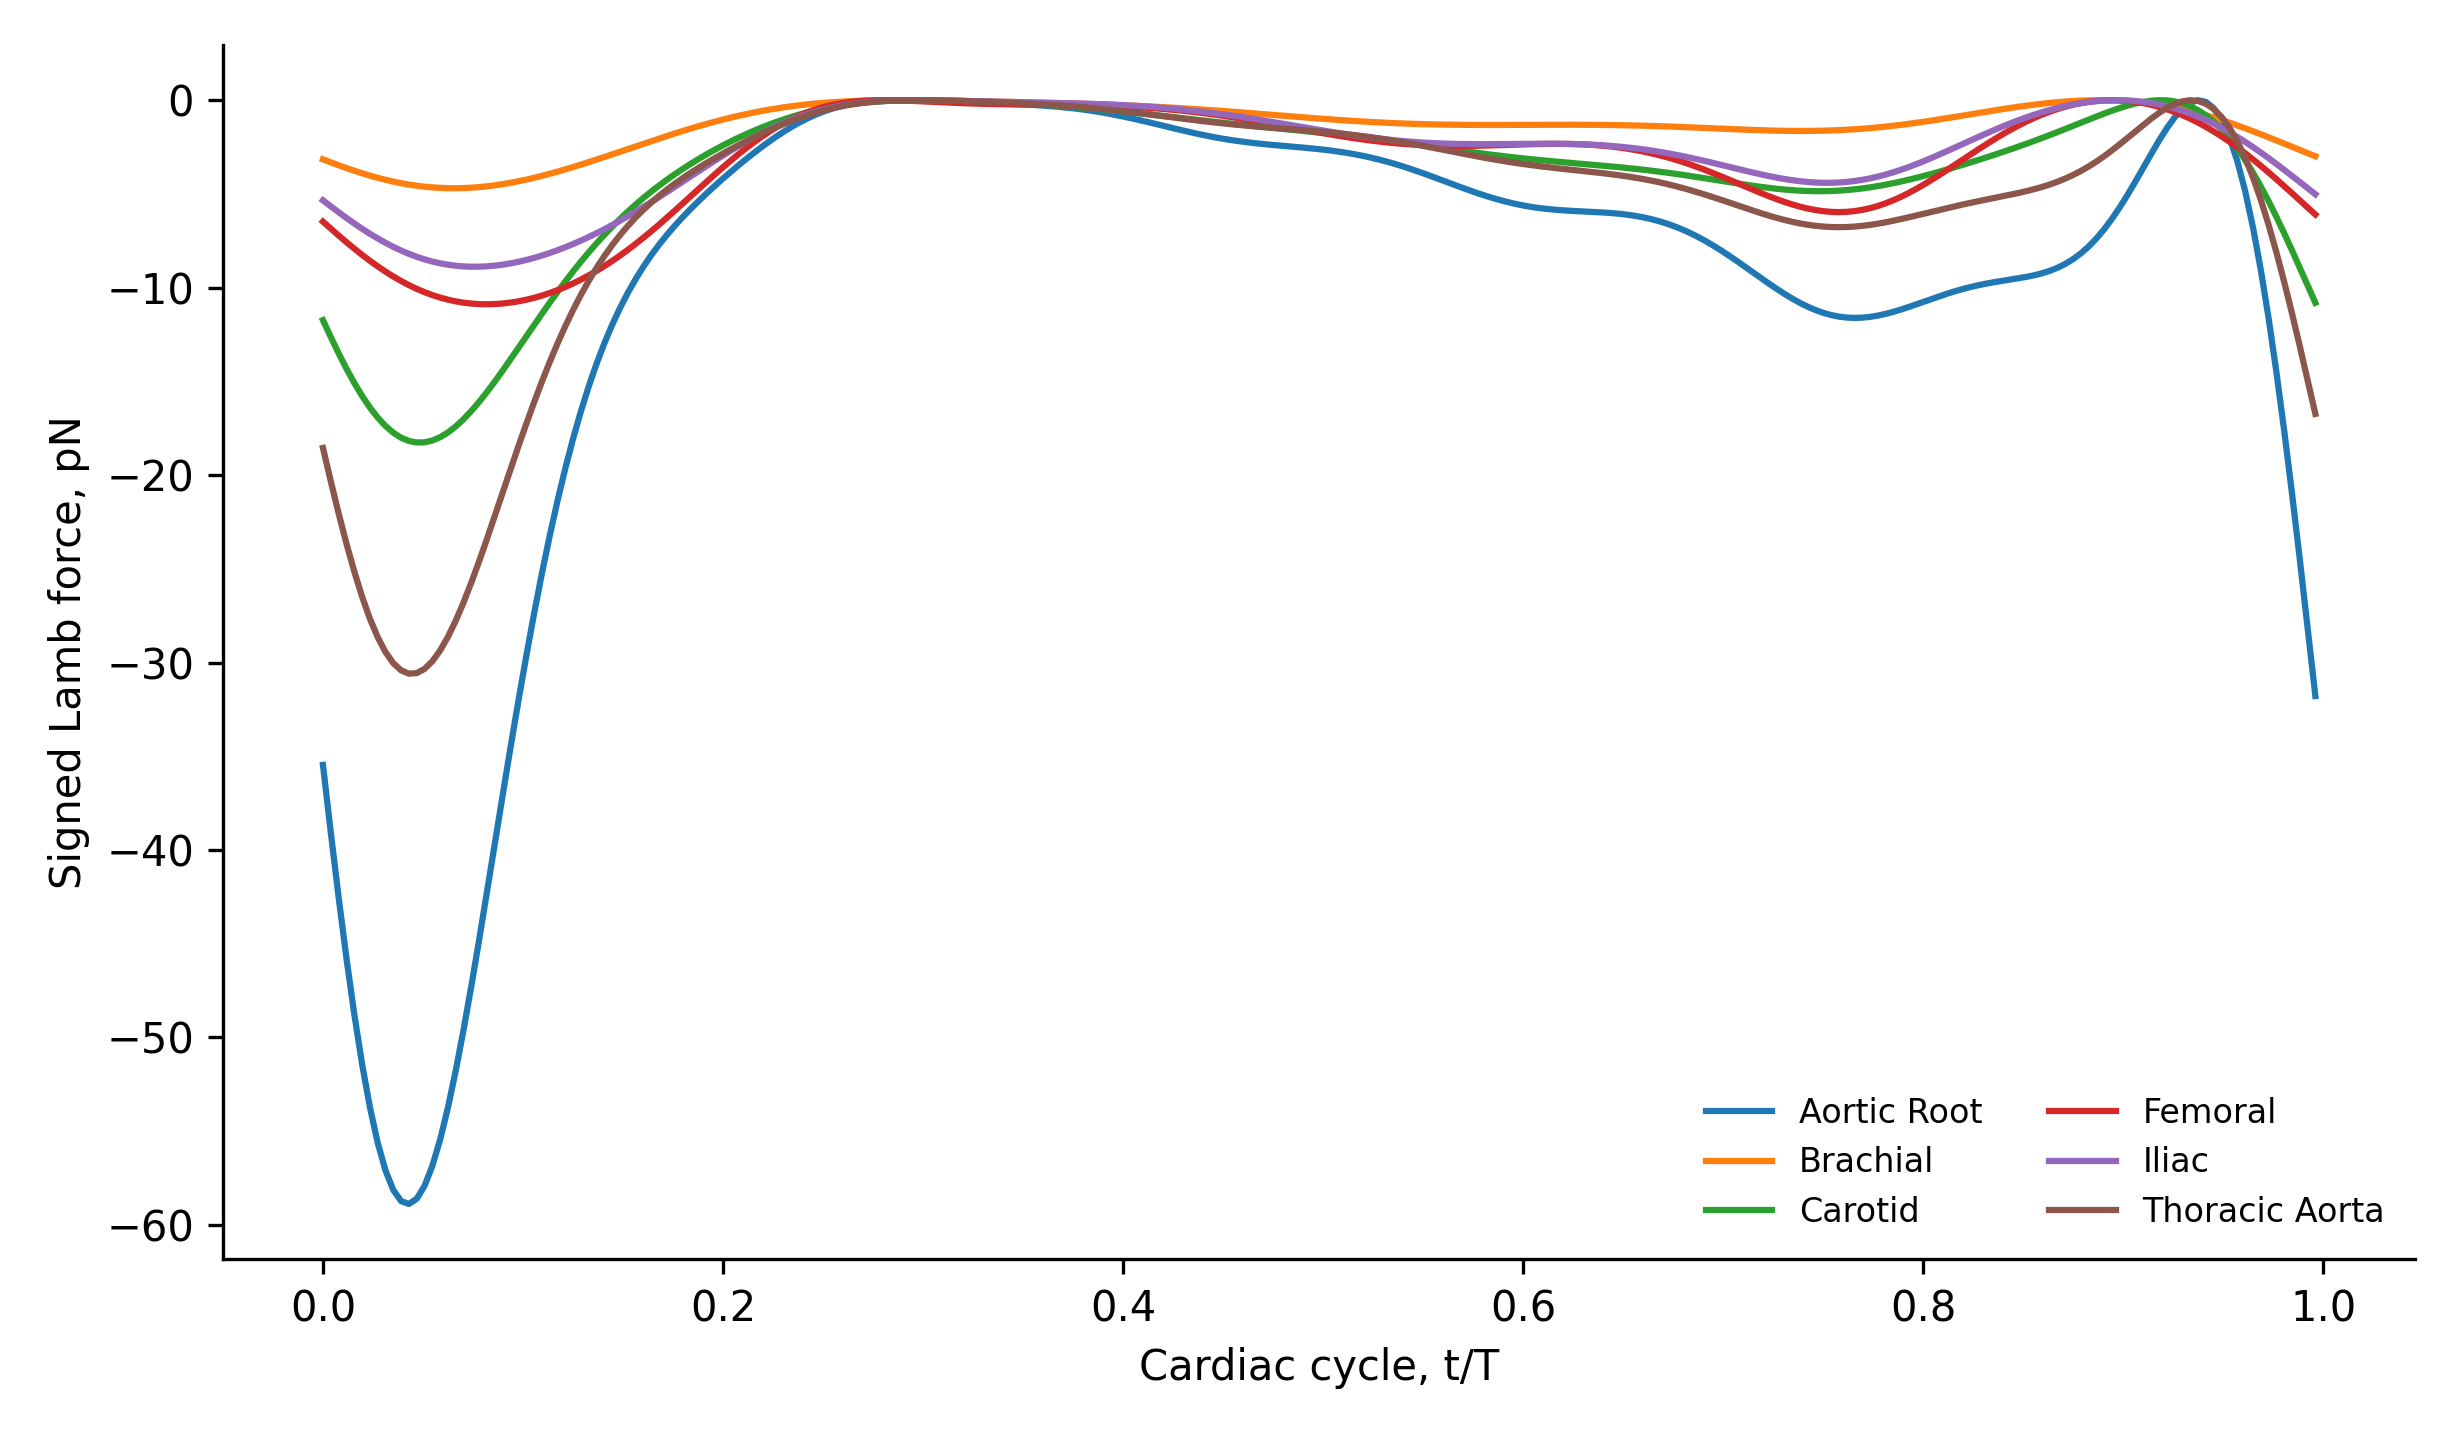

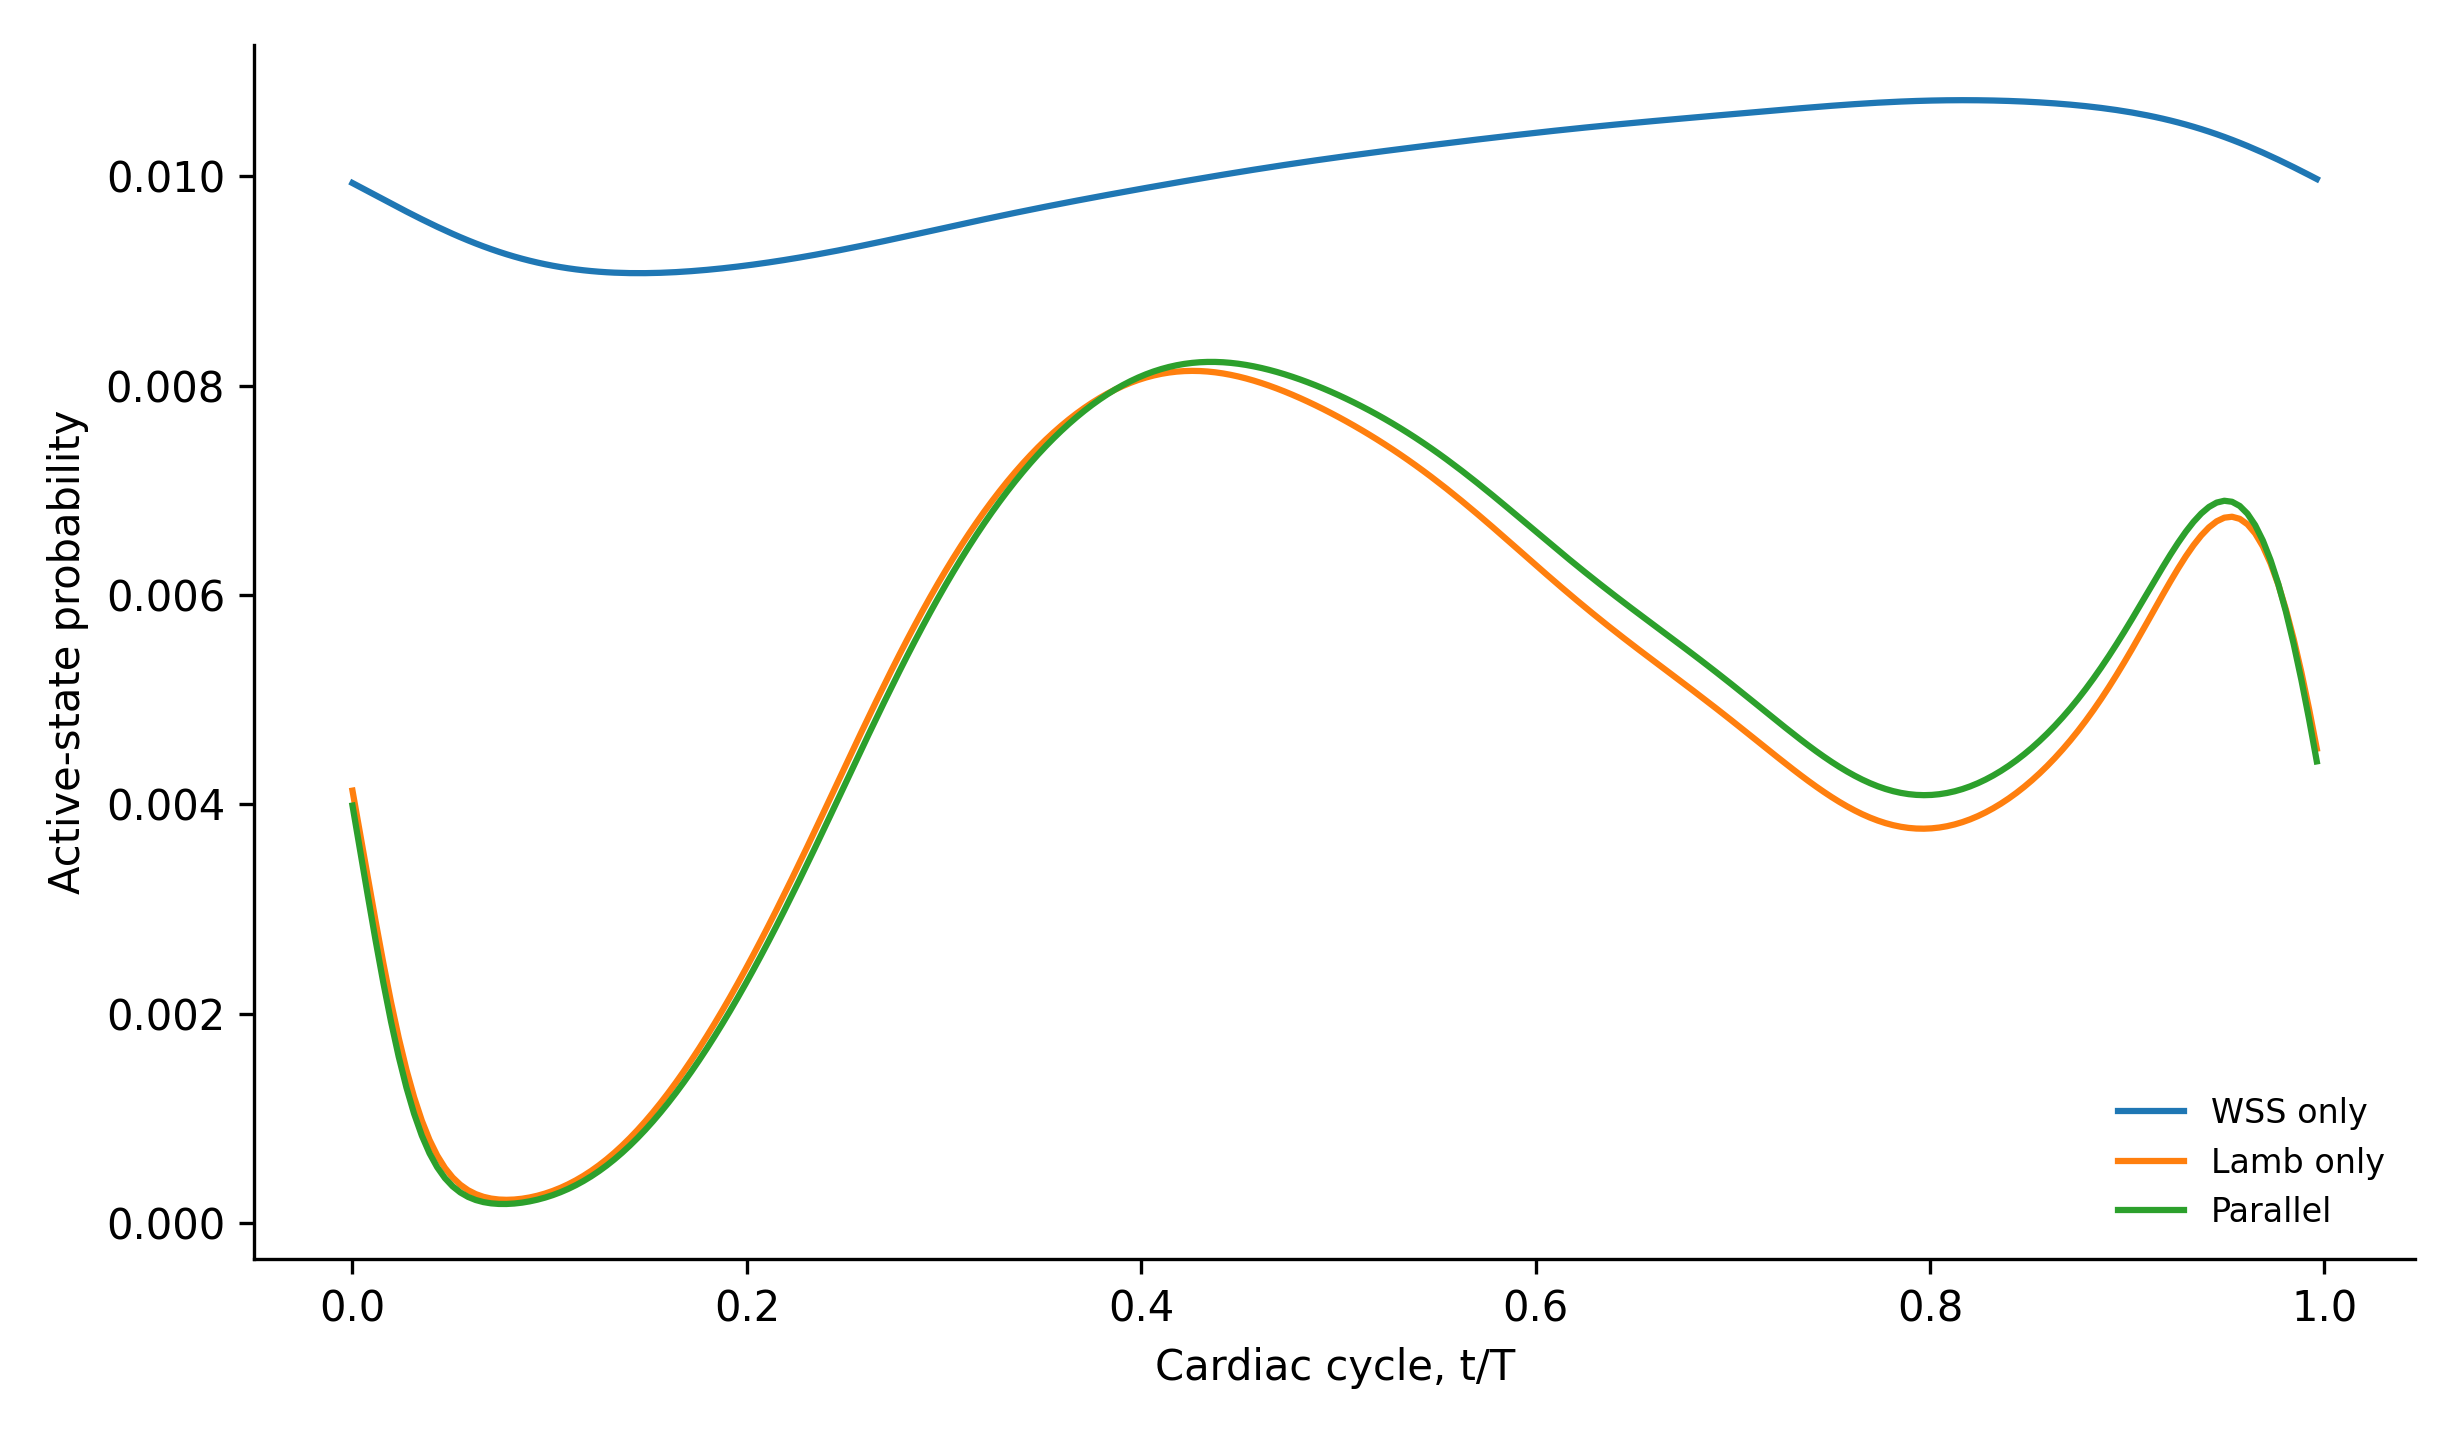

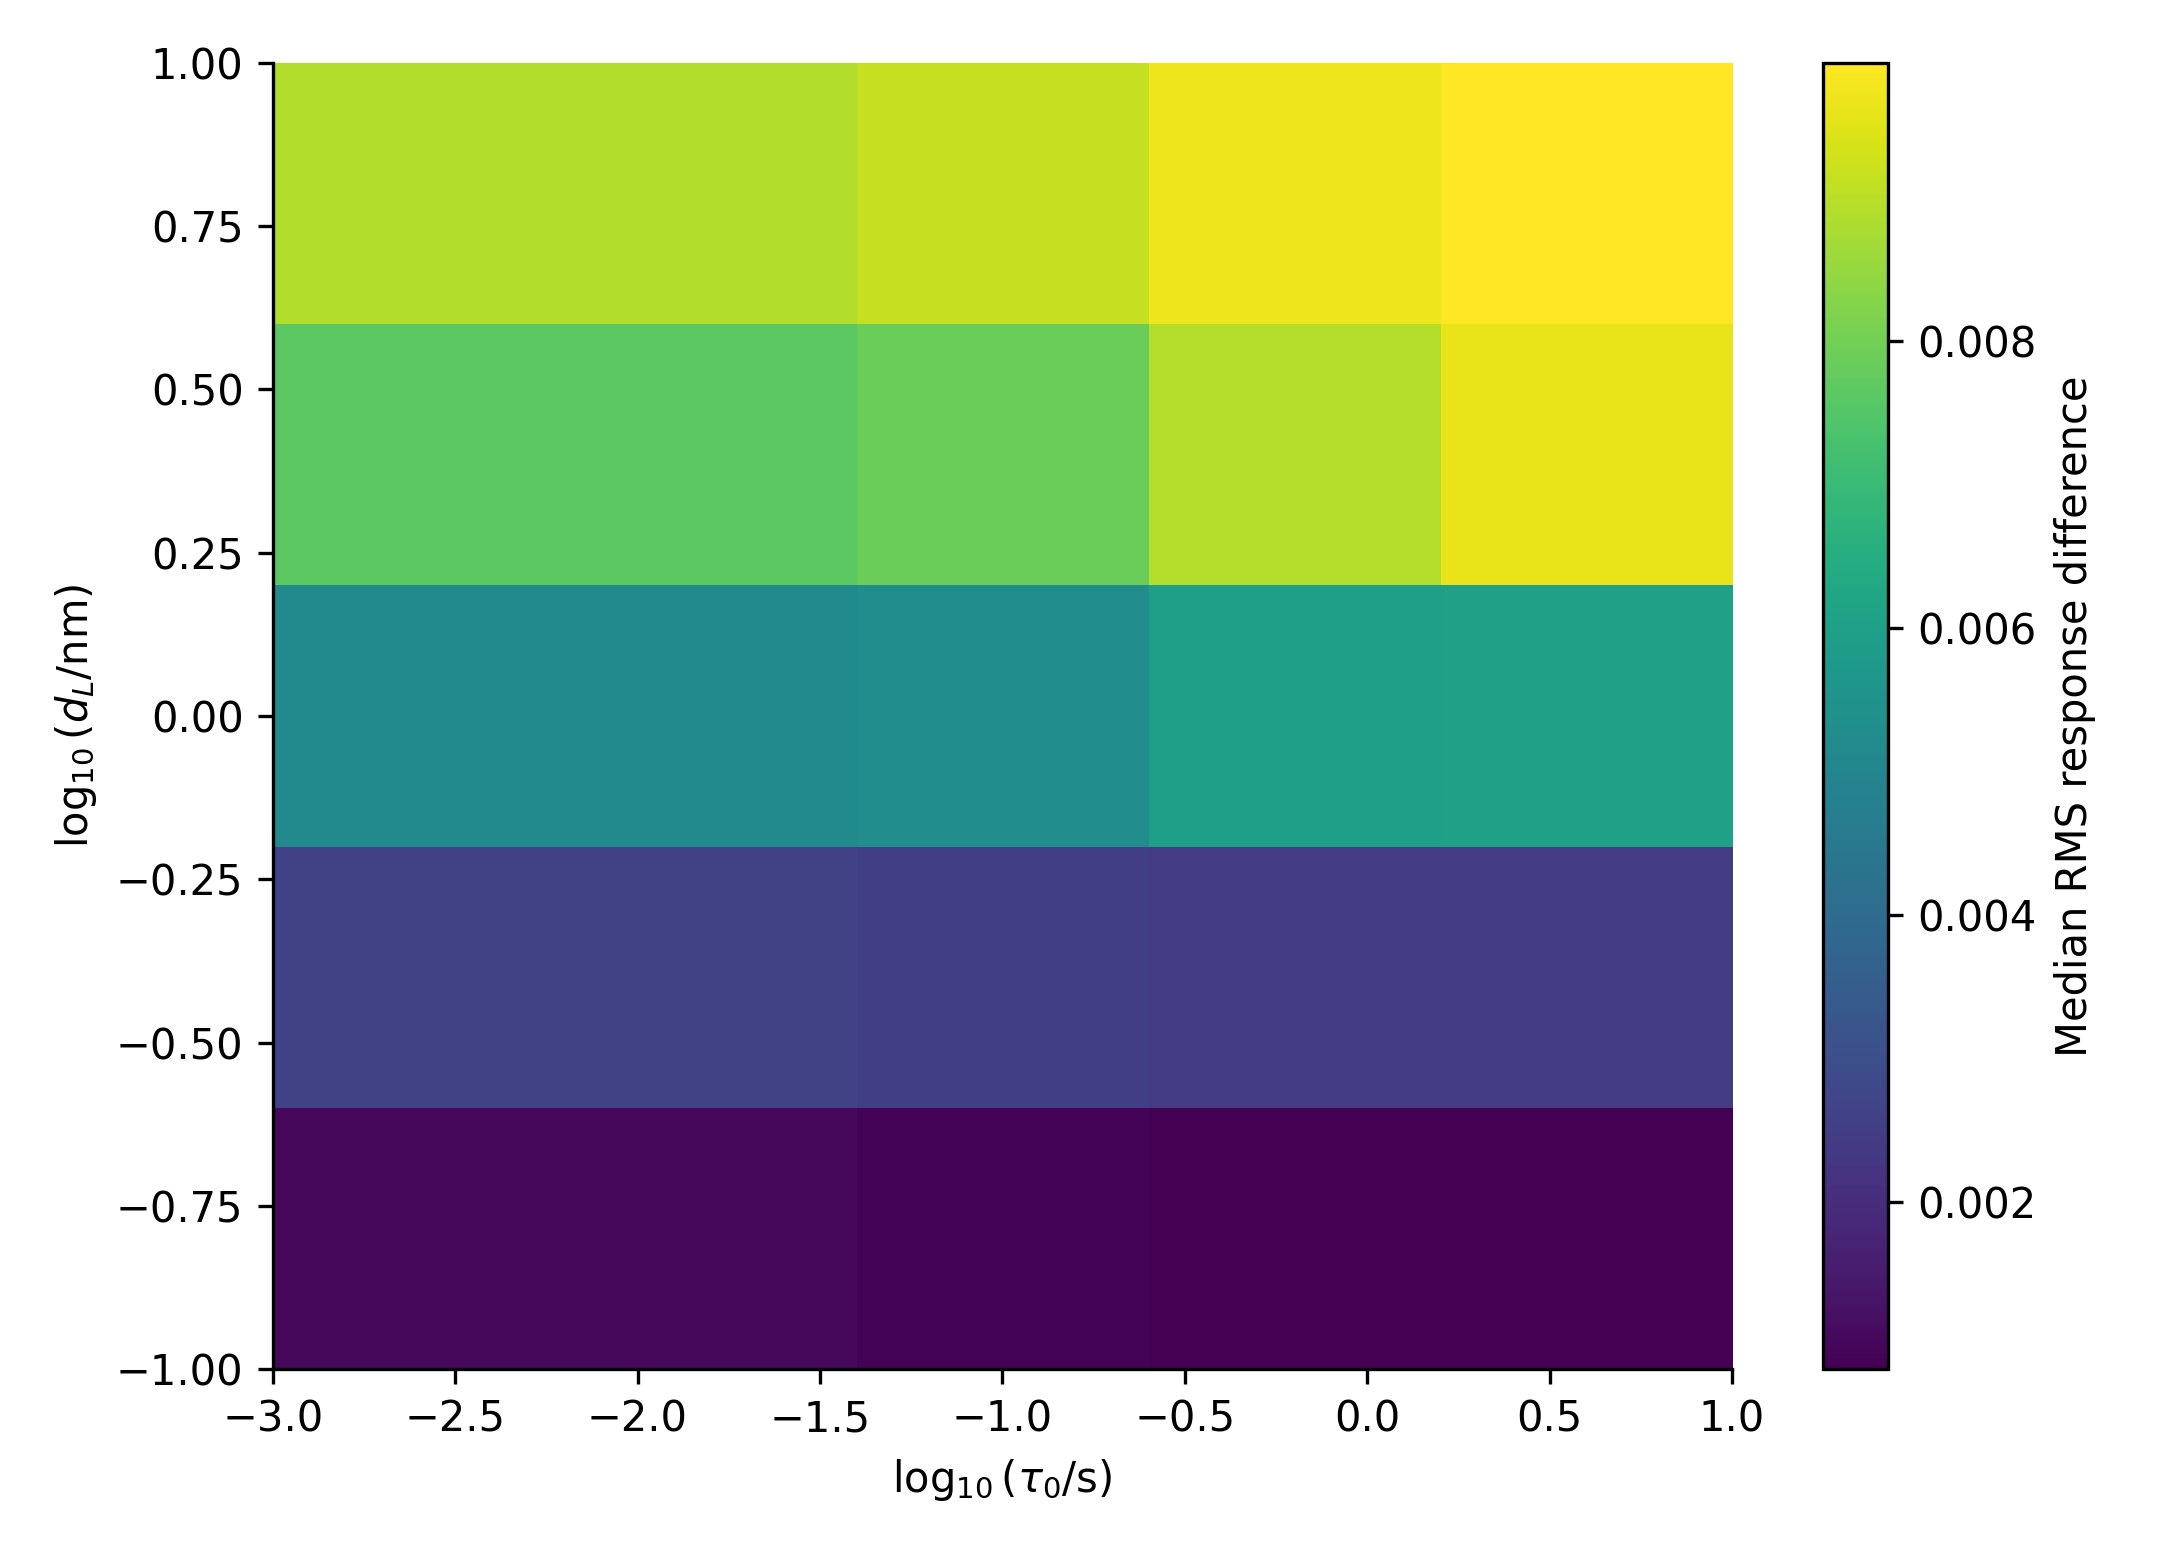

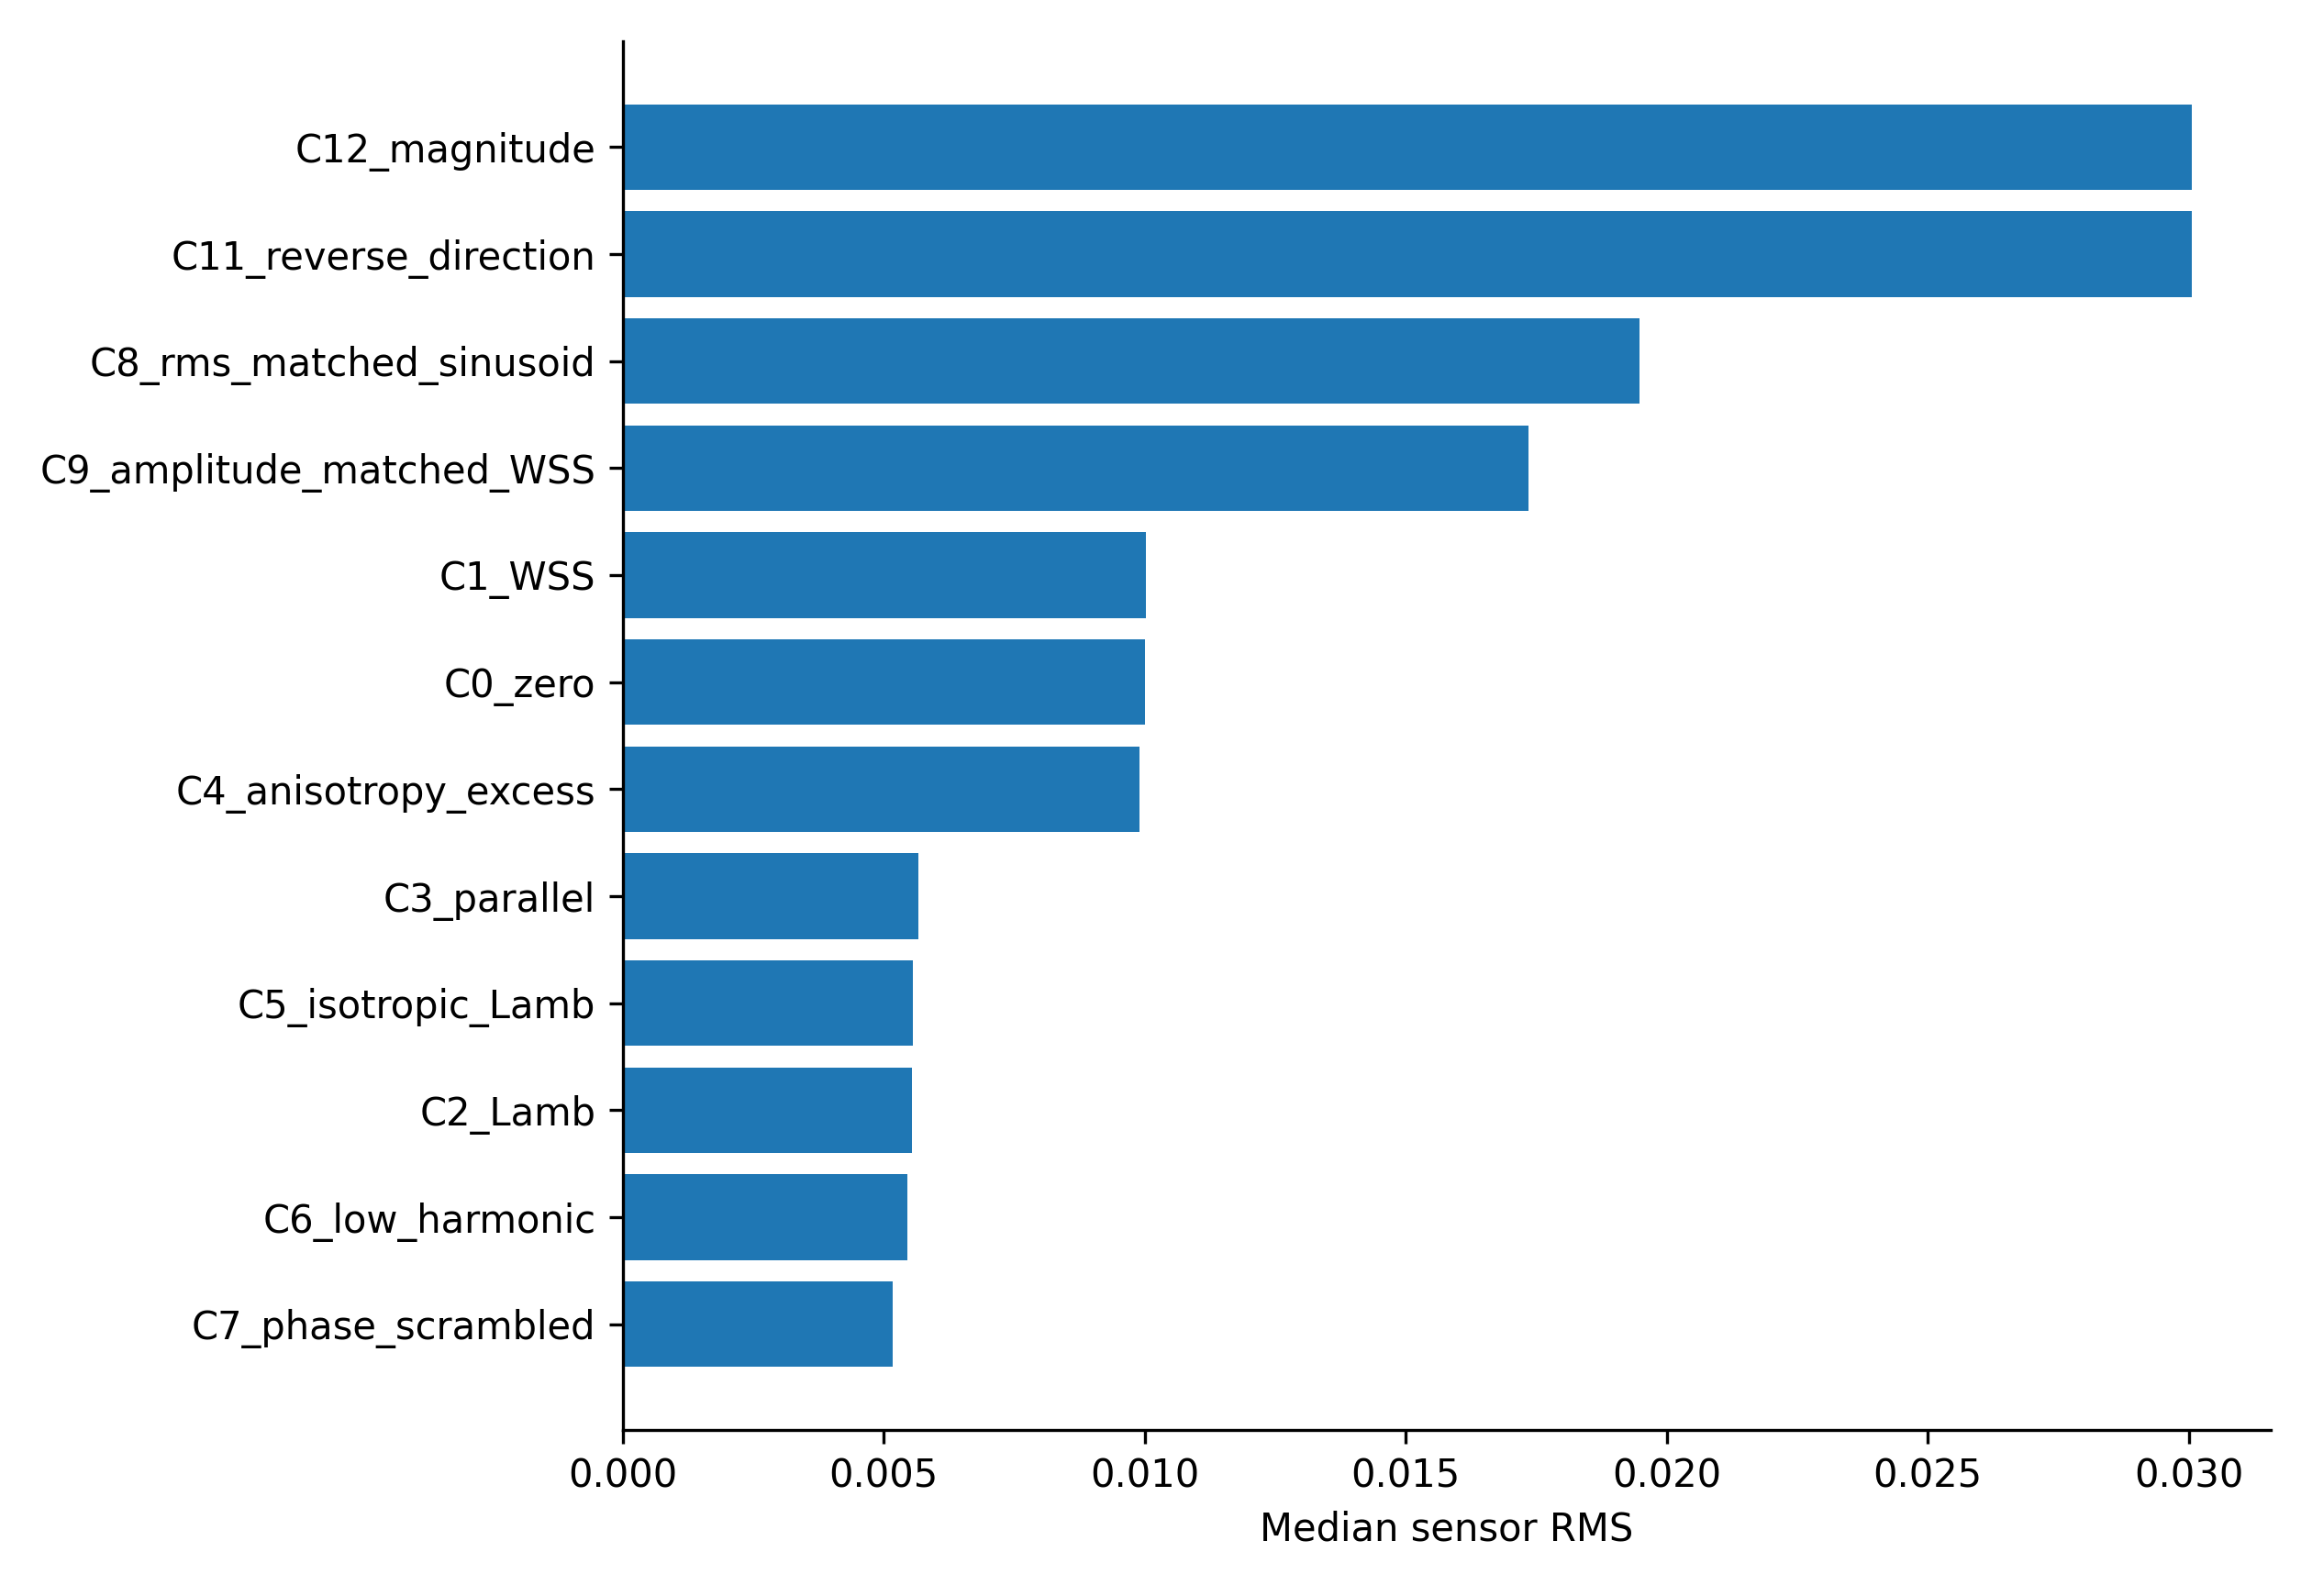

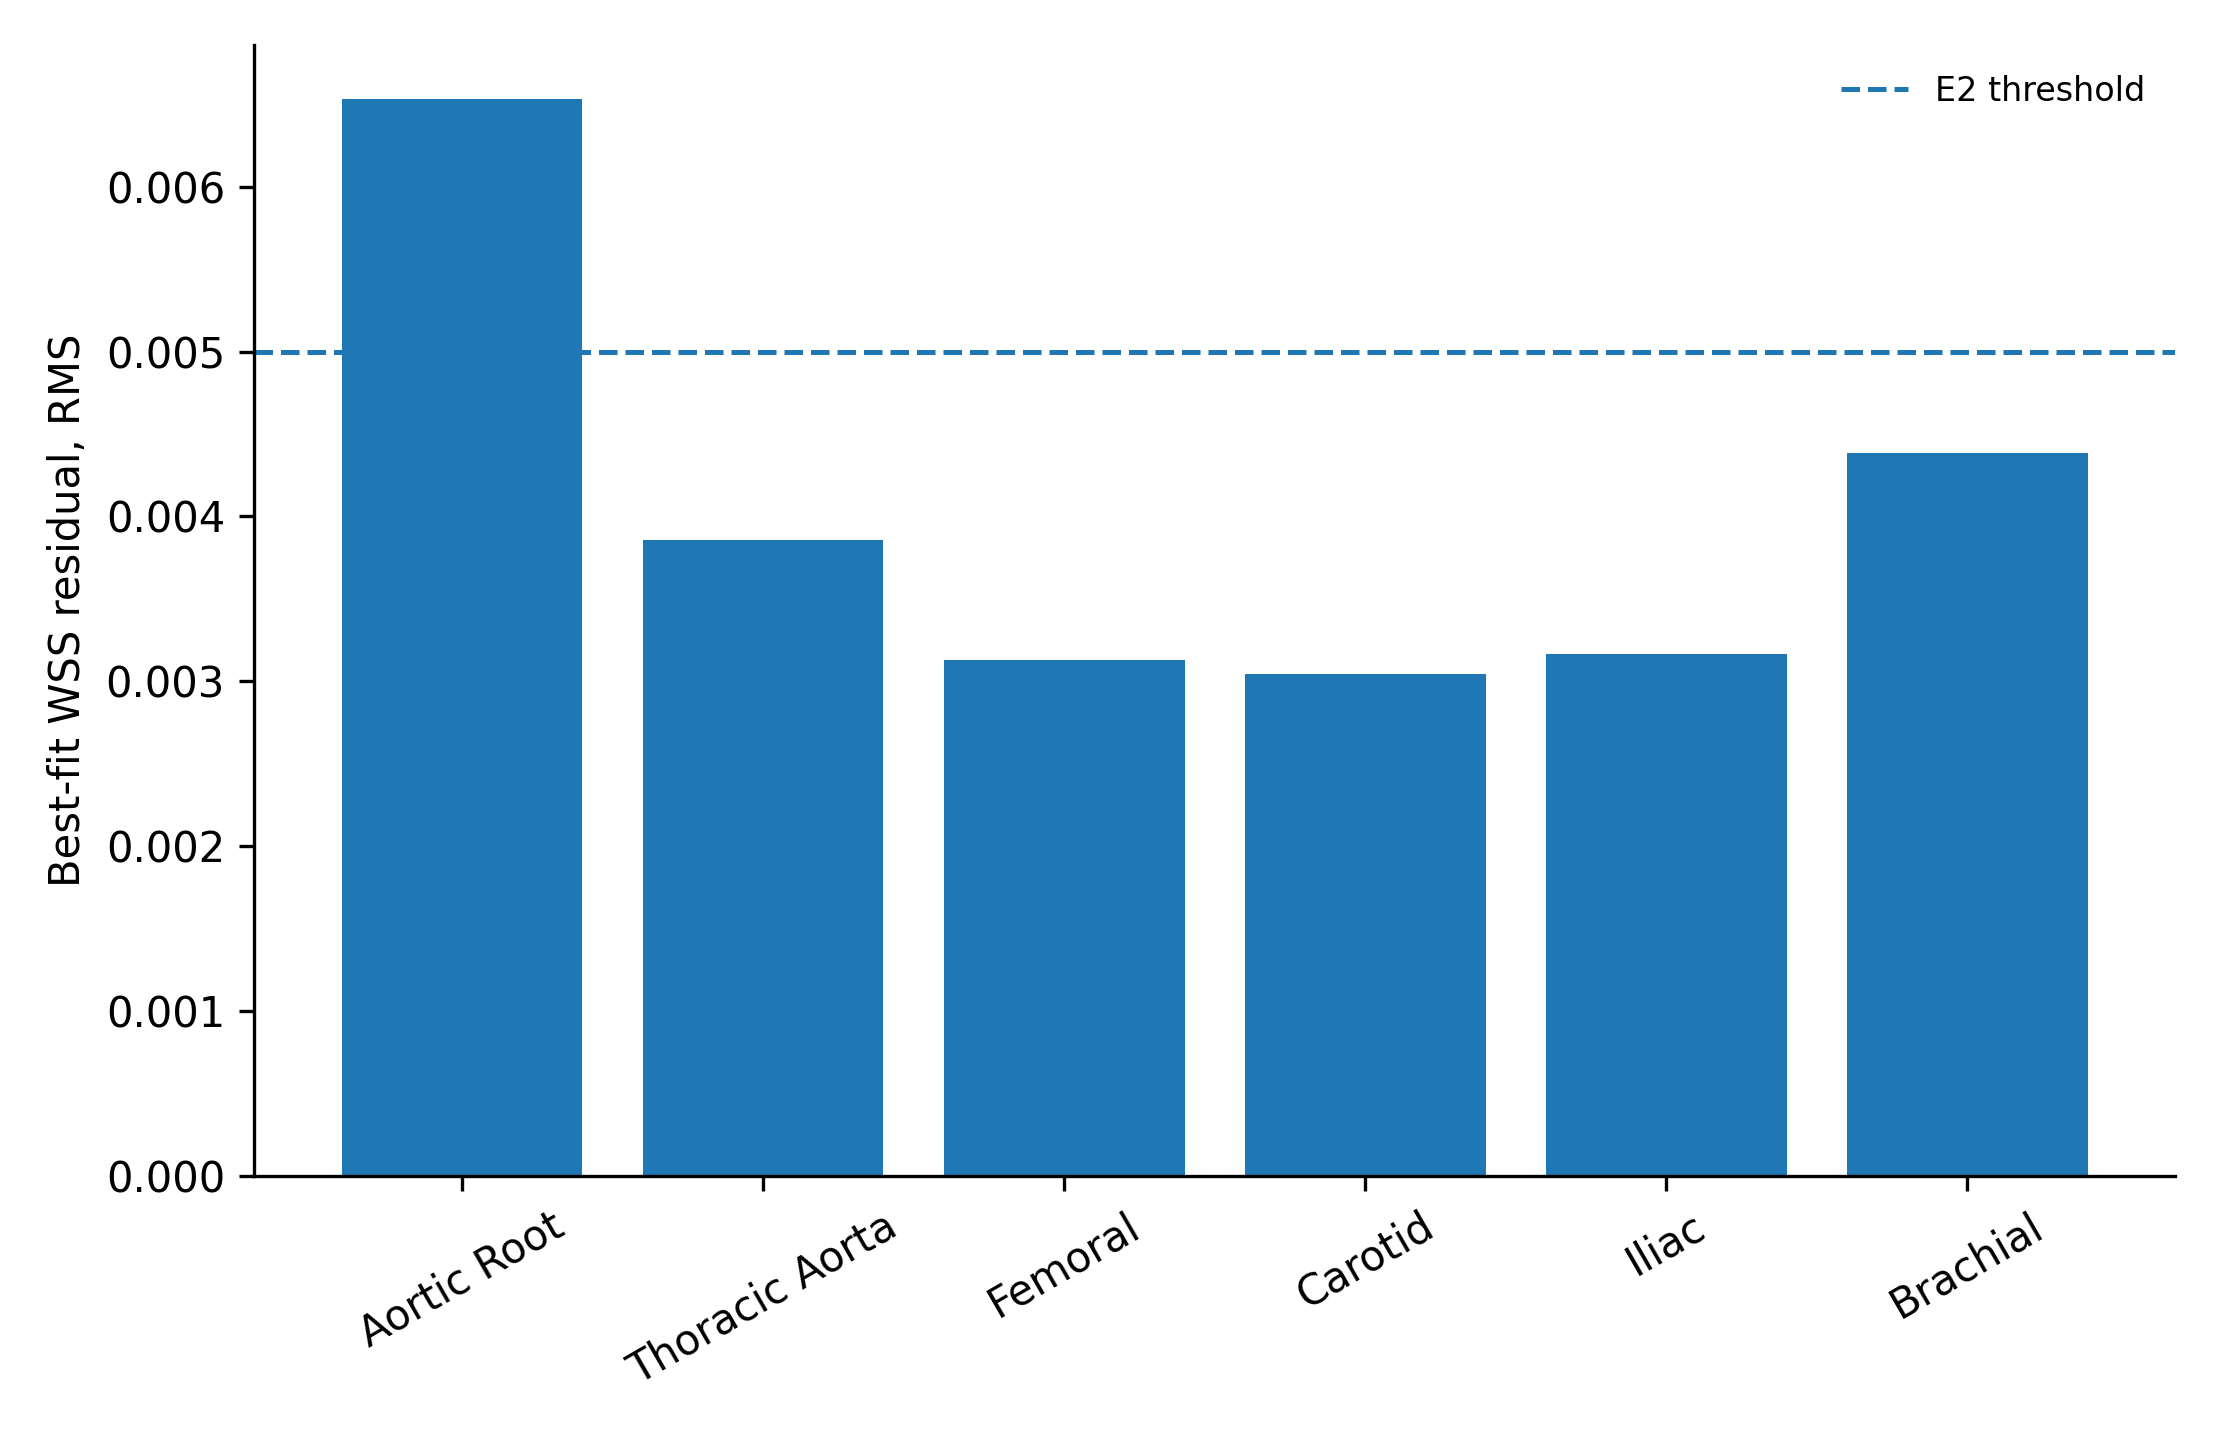

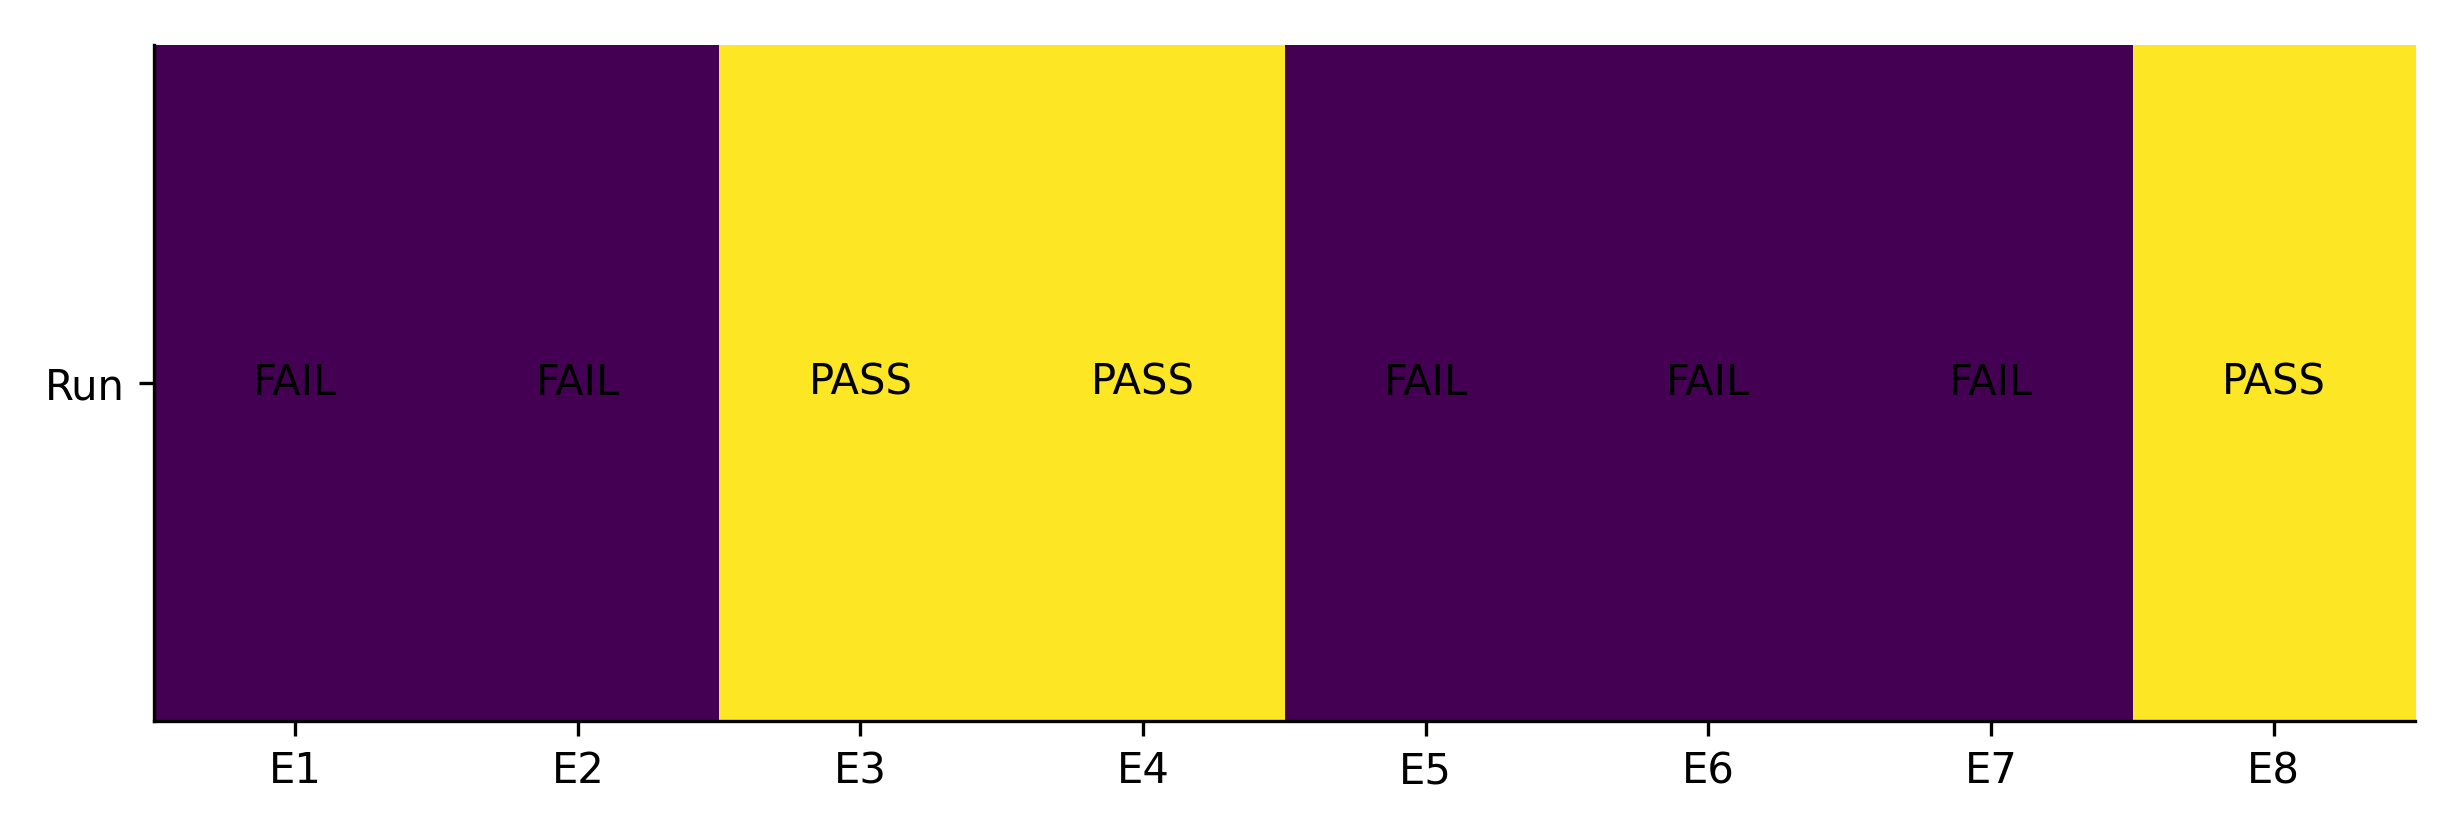

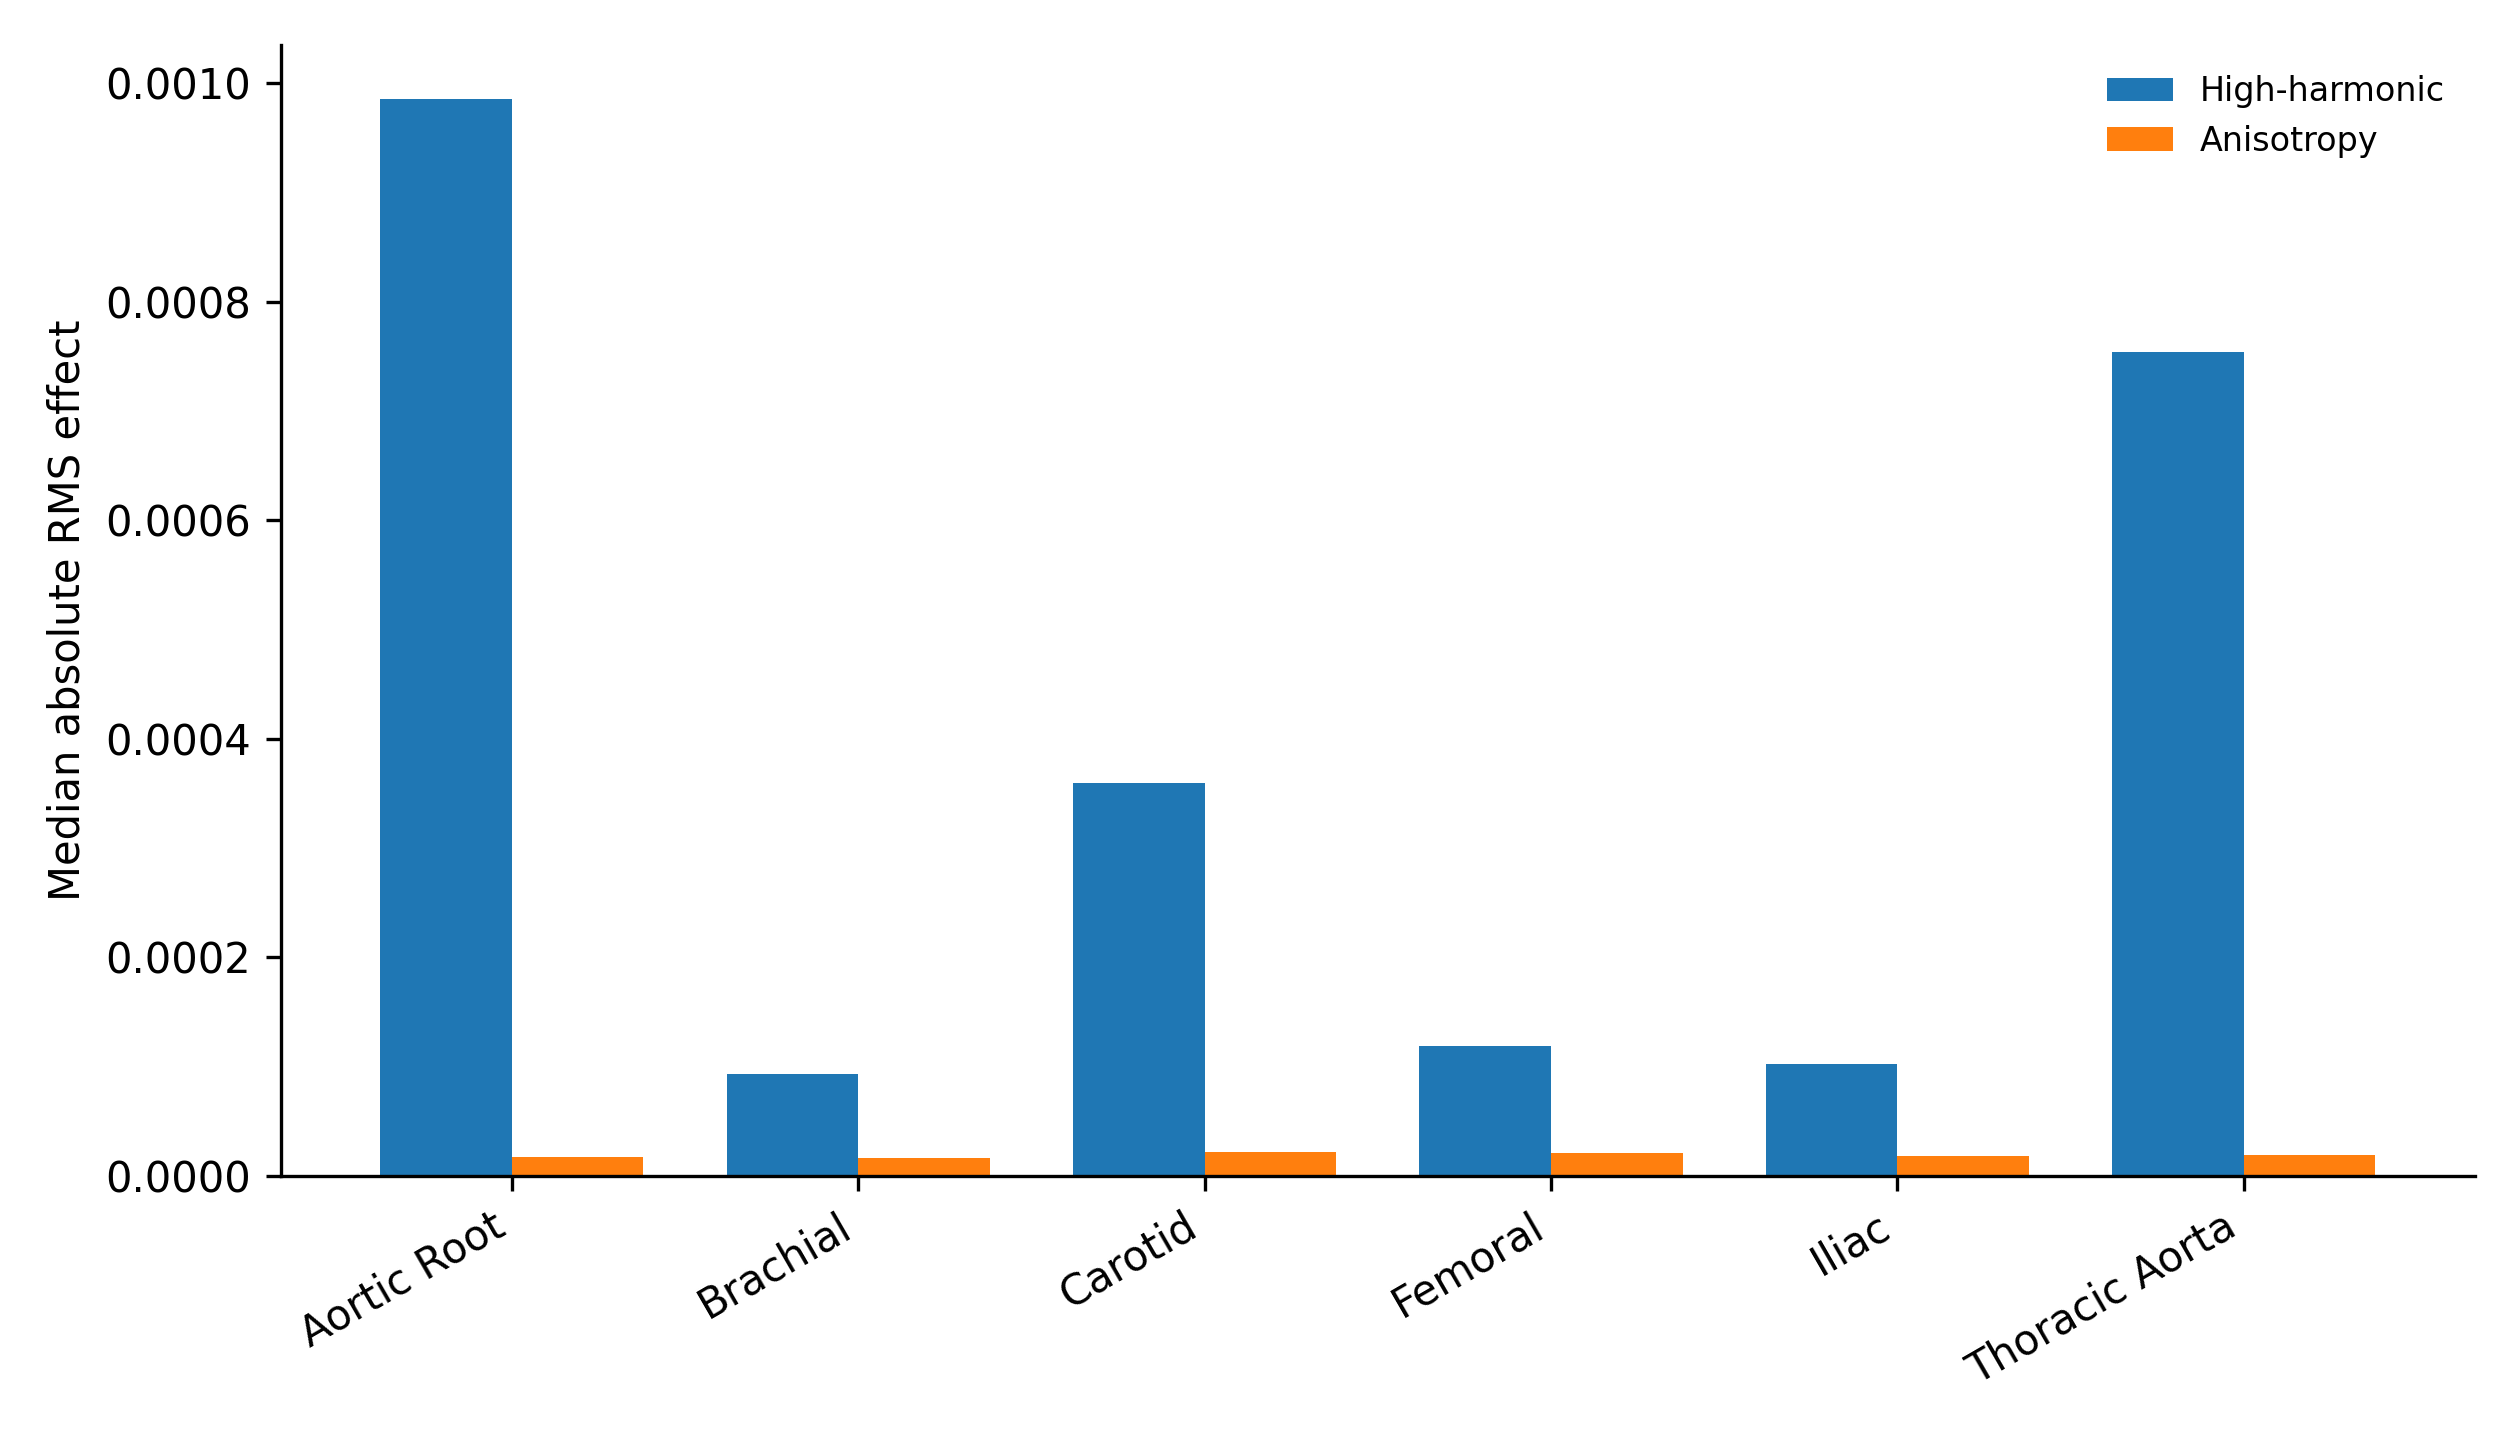

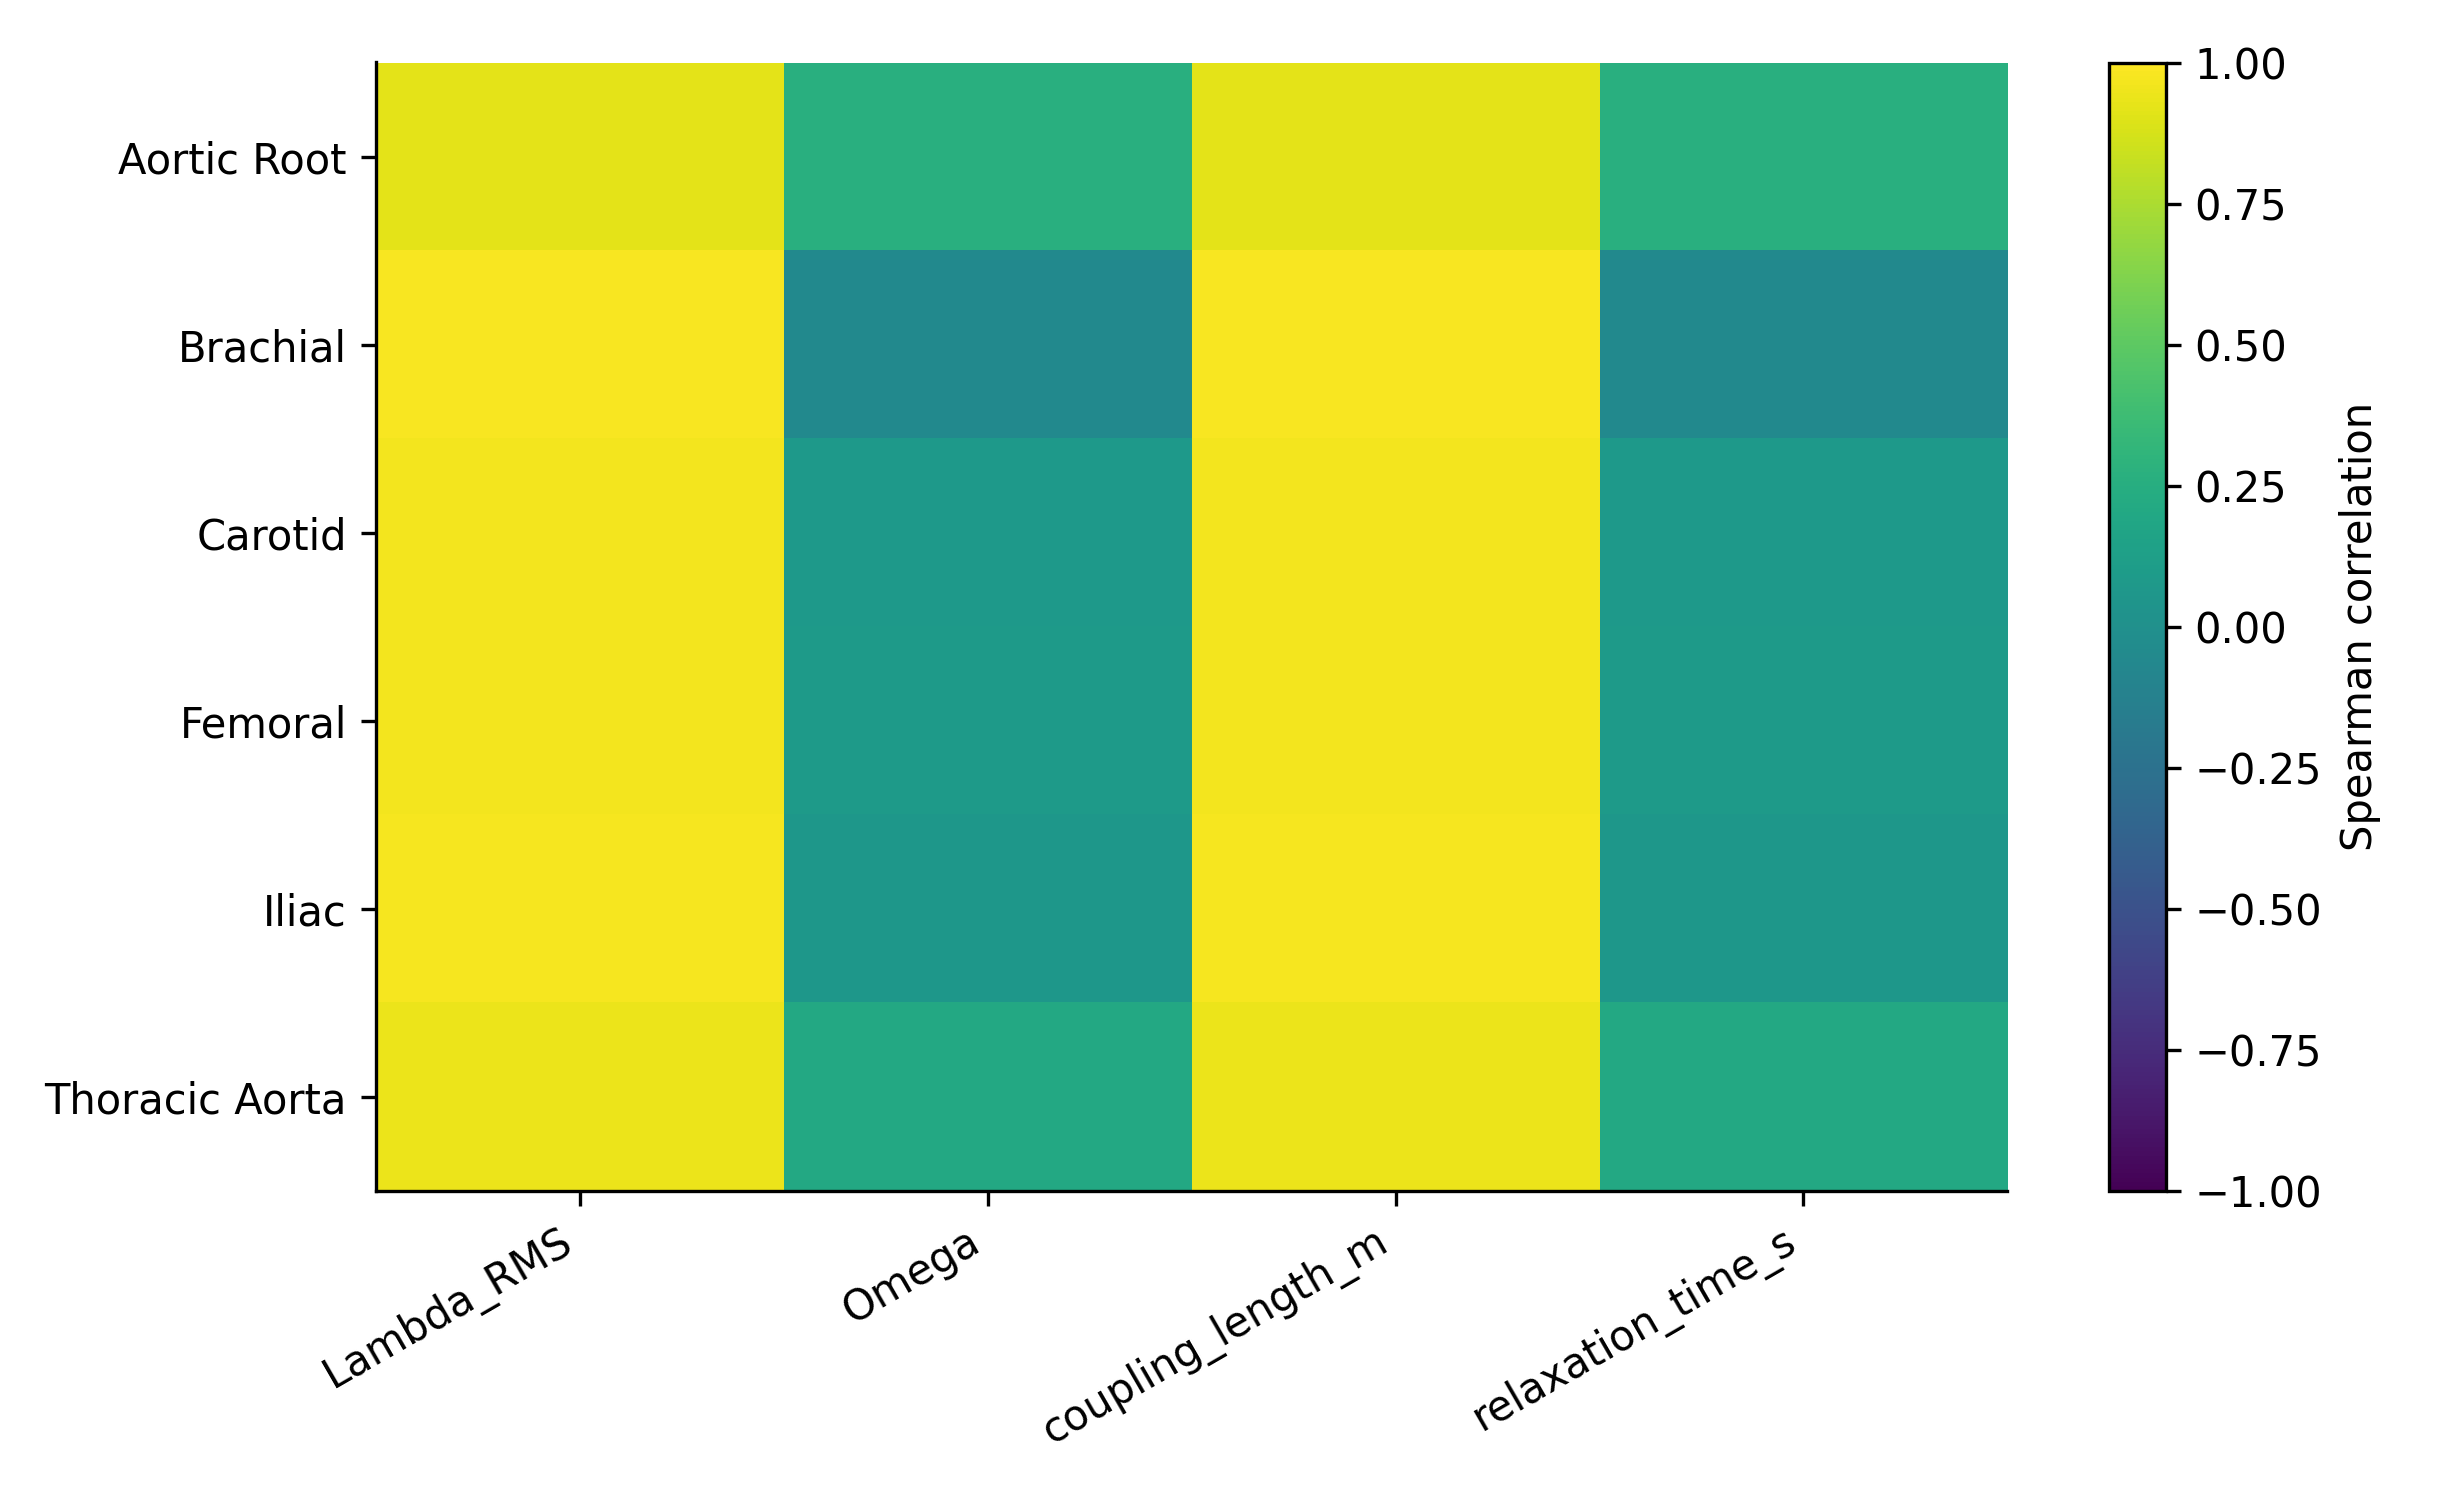

In [12]:
FIGURE_PATHS=generate_publication_figures(RUN_ROOT/'figures',WAVEFORM_TABLE,CONTROL_TABLE,PARAMETER_GRID,SURROGATE_TABLE,GATE_TABLE,DOMINANCE_TABLE)
for p in FIGURE_PATHS: STORE.register_file(RUN_ID,f'figures/{p.name}','output')
for p in FIGURE_PATHS:
    if p.suffix=='.png': display(Image(filename=str(p),width=850))

## 12. Complete dataset, manifests and checksums

In [13]:
export_publication_dataset(STORE,RUN_ID,waveform_table=WAVEFORM_TABLE,control_table=CONTROL_TABLE,parameter_grid=PARAMETER_GRID,surrogate_table=SURROGATE_TABLE,gate_table=GATE_TABLE,dominance_table=DOMINANCE_TABLE,hydrodynamics=HYDRODYNAMICS)
for relative,table in {'summaries/sobol_sensor_design.csv':SOBOL_SENSOR_DESIGN,'summaries/physiological_design.csv':PHYSIOLOGICAL_DESIGN,'summaries/physiological_coverage.csv':PHYSIOLOGICAL_SUMMARY,'spectra/physiological_force_spectra.csv':PHYSIOLOGICAL_SPECTRA}.items(): STORE.write_csv(f'runs/{RUN_ID}/{relative}',table); STORE.register_file(RUN_ID,relative,'output')
write_json(RUN_ROOT/'summaries/wss_surrogate_parameters.json',SURROGATE_PARAMETERS); STORE.register_file(RUN_ID,'summaries/wss_surrogate_parameters.json','output')
bundle=RUN_ROOT/'publication_bundle'; bundle.mkdir(exist_ok=True)
for src in [PROJECT_ROOT/'data/data_dictionary.csv',PROJECT_ROOT/'data/source_manifest.csv',PROJECT_ROOT/'data/v2_harmonic_inputs.csv',PROJECT_ROOT/'data/publication_dataset_schema.json',PROJECT_ROOT/'configs/effect_gates.json',PROJECT_ROOT/'configs/numerical_thresholds.json',PROJECT_ROOT/'docs/DATA_AVAILABILITY.md',PROJECT_ROOT/'docs/CODE_AVAILABILITY.md',CONFIG_PATH]: shutil.copy2(src,bundle/src.name)
CHECKSUM_PATH=STORE.write_checksums(f'runs/{RUN_ID}','provenance/checksums.sha256'); STORE.set_status(RUN_ID,'complete'); print(RUN_ROOT,CHECKSUM_PATH)

/content/drive/MyDrive/picoNewton_v3/runs/run_295c46bc2f9dbb08 /content/drive/MyDrive/picoNewton_v3/runs/run_295c46bc2f9dbb08/provenance/checksums.sha256


## 13. Availability, limitations and claim selection

In [14]:
CLAIM_ACTIONS=GATE_TABLE.assign(manuscript_action=np.where(GATE_TABLE.passed,'candidate claim retained','claim removed or explicitly qualified'))
display(CLAIM_ACTIONS)
display(Markdown((PROJECT_ROOT/'docs/DATA_AVAILABILITY.md').read_text())); display(Markdown((PROJECT_ROOT/'docs/CODE_AVAILABILITY.md').read_text()))

,criterion_id,name,passed,observed,manuscript_action
0,E1,Core Lamb detectability,False,3/6 arteries at >=60%; overall 0.656; basis=ph...,claim removed or explicitly qualified
1,E2,Held-out WSS nonredundancy,False,"[{""artery_id"": ""carotid"", ""artery_name"": ""Caro...",claim removed or explicitly qualified
2,E3,Contiguous parameter support,True,"{""aortic_root"": [true, [{""points"": 17, ""d_span...",candidate claim retained
3,E4,Directional specificity,True,6/6 arteries at >=60%,candidate claim retained
4,E5,High-harmonic specificity,False,0/6 arteries at >=25%,claim removed or explicitly qualified
5,E6,Anisotropy-specific detectability,False,0/6 arteries at >=25%,claim removed or explicitly qualified
6,E7,Robust full-range effect,False,5th-percentile effect >=0.005 in 2/6 arteries,claim removed or explicitly qualified
7,E8,Model-class transparency,True,"signed, reversed-direction and magnitude class...",candidate claim retained


# Draft Data Availability statement

All numerical inputs required for the primary v2-preserving analysis, curated
parameter tables, complete configurations, hydrodynamic and mechanosensory
summary tables, multidimensional signal files, figure source data, checksums and
environment metadata will be deposited in a versioned public research-data
repository with a DOI before manuscript submission.

The repository bundle identifies every external source, its licence, checksum
and transformation. The Jones virtual-patient database and MIMIC-III waveform
database are external third-party resources and will not be redistributed. The
notebook provides optional source adapters and stable identifiers. Primary
manuscript results do not require MIMIC-III access.


# Draft Code Availability statement

The executable notebook, Python modules, tests and locked configurations are
available in the public `khalid-saqr/picoNewton` repository under the
`picoNewton_v3/` directory. The publication release will be tagged and archived
with a DOI.

The workflow exposes separate `reproduction` and `verified` solver modes,
records the Git commit and input hashes in every run manifest, and regenerates
all tables and figures from source data without manual figure editing.
